# KeyPoint MoSeq Testing
Runs KeyPoint-MoSeq on sleap tracks. Objective is to evaluate feasability and output useful figures/videos.

NOTES:
- Filepath strings can't have brackets (need to change how campy makes session names)

## 1. Setup

In [1]:
### Imports.

import os
import cv2
import itertools
import numpy as np
import networkx as nx
from tqdm import trange
import keypoint_moseq as kpms
import matplotlib.pyplot as plt

In [21]:
### Variables.

# CAMERA_DIRECTORY = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_2/(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2/Camera2"
# CAMERA_VIDEO_FILENAME = [f for f in os.listdir(CAMERA_DIRECTORY) if f.endswith(".mp4") and "tracks" not in f][0]
# CAMERA_VIDEO_FILEPATH = CAMERA_DIRECTORY + "/" + CAMERA_VIDEO_FILENAME
# TRACKS_FILEPATH = os.path.join(CAMERA_DIRECTORY, "black_inference.slp")
# SESSION_NAME = CAMERA_DIRECTORY.split("/")[-2]
# TRACKS_FILEPATH_3D = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_2/(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2/black_triangulated.h5"

CAMERA_DIRECTORY = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_3/(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3/Camera2"
CAMERA_VIDEO_FILENAME = [f for f in os.listdir(CAMERA_DIRECTORY) if f.endswith(".mp4") and "tracks" not in f][0]
CAMERA_VIDEO_FILEPATH = CAMERA_DIRECTORY + "/" + CAMERA_VIDEO_FILENAME
TRACKS_FILEPATH = os.path.join(CAMERA_DIRECTORY, "black_inference.slp")
SESSION_NAME = CAMERA_DIRECTORY.split("/")[-2]
TRACKS_FILEPATH_3D = r"Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-25/Bl6SW_3/(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3/black_triangulated.h5"

In [22]:
### Make sure all filepath exist.

assert os.path.exists(CAMERA_VIDEO_FILEPATH), f"Camera video file does not exist: {CAMERA_VIDEO_FILEPATH}"
assert os.path.exists(TRACKS_FILEPATH), f"Tracks file does not exist: {TRACKS_FILEPATH}"
assert os.path.exists(TRACKS_FILEPATH_3D), f"3D Tracks file does not exist: {TRACKS_FILEPATH_3D}"

## 2. KPMS initialization and configuration

In [24]:
### Create new KPMS project.

# Load config.
project_dir = os.path.join(os.getcwd(), f"{SESSION_NAME}_test_project")
config = lambda: kpms.load_config(project_dir)

# Load sleap file. NOTE: using original tracks file for overhead view for project setup.
kpms.setup_project(project_dir, sleap_file=TRACKS_FILEPATH, overwrite=True)

# Update config file with parameters for tracking.
kpms.update_config(
    project_dir,
    video_dir=CAMERA_VIDEO_FILEPATH,
    anterior_bodyparts=["Nose"],
    posterior_bodyparts=["TTI"],
    use_bodyparts=["Nose", "Ear_L", "Ear_R", "Head", "Neck", "Shoulder_left",
                    "Shoulder_right", "Haunch_left", "Haunch_right", "Trunk", "TTI"] # Use everything but the tail.
)

# Load data.
coordinates, confidences, bodyparts = kpms.load_keypoints(TRACKS_FILEPATH_3D, "sleap-anipose")

# format data for modeling
data, metadata = kpms.format_data(coordinates, confidences, **config())

Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  1.13it/s]


In [31]:
### Calibration.
# NOTE: only supported for 2D tracking.

# kpms.noise_calibration(project_dir, coordinates, confidences, **config())

>=90.0% of variance exlained by 7 components.


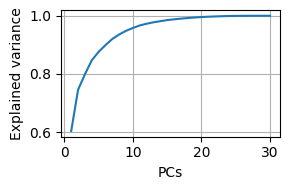

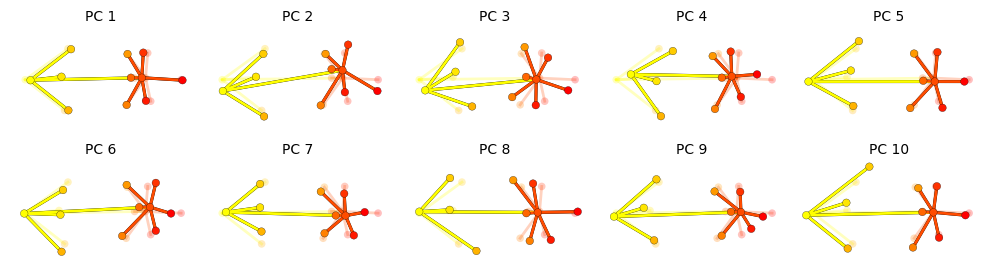

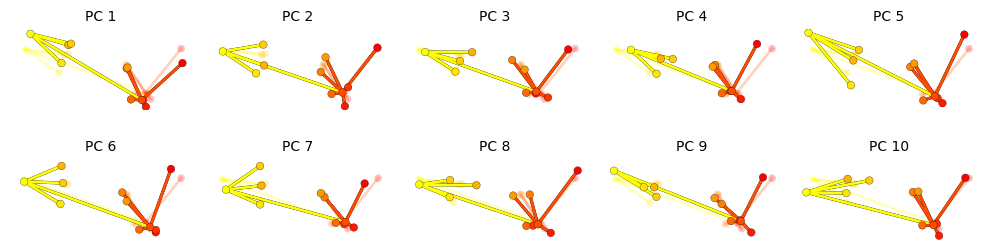

Saved interactive plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\pcs.html


Number of PCs needed to explain 90% of variance: 7


In [39]:
### Fit PCA.

pca = kpms.fit_pca(**data, **config())
kpms.save_pca(pca, project_dir)

kpms.print_dims_to_explain_variance(pca, 0.9)
kpms.plot_scree(pca, project_dir=project_dir)
kpms.plot_pcs(pca, project_dir=project_dir, **config());

num_pcs_needed_for_90_var = int(np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.9)[0][0] + 1)
print(f"Number of PCs needed to explain 90% of variance: {num_pcs_needed_for_90_var}")

In [41]:
### Update number of latent dimensions to equal number of PCs needed for 90% variance explained.

kpms.update_config(project_dir, latent_dim=num_pcs_needed_for_90_var)

## 3. Kappa sweep

In [ ]:
### Sweep a range of kappa values to find one for target motif length.

kappas = np.logspace(6, 12, 5)
decrease_kappa_factor = 10
num_ar_iters = 50
num_full_iters = 200

prefix = "kappa_sweep"

for kappa in kappas:
    print(f"Fitting model with kappa={kappa}")
    model_name = f"{prefix}-{kappa}"
    model = kpms.init_model(data, pca=pca, **config(), location_aware=True)

    # stage 1: fit the model with AR only
    model = kpms.update_hypparams(model, kappa=kappa)
    model = kpms.fit_model(
        model,
        data,
        metadata,
        project_dir,
        model_name,
        ar_only=True,
        num_iters=num_ar_iters,
        save_every_n_iters=25,
        location_aware=True
    )[0];

    # stage 2: fit the full model
    model = kpms.update_hypparams(model, kappa=kappa/decrease_kappa_factor)
    kpms.fit_model(
        model,
        data,
        metadata,
        project_dir,
        model_name,
        ar_only=False,
        start_iter=num_ar_iters,
        num_iters=num_full_iters,
        save_every_n_iters=25,
        location_aware=True
    );

kpms.plot_kappa_scan(kappas, project_dir, prefix)

Fitting model with kappa=1000000.0


ConstructorError: could not determine a constructor for the tag 'tag:yaml.org,2002:python/object/apply:numpy.core.multiarray.scalar'
  in "z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\config.yml", line 107, column 15

Kappa = 1e9 targets mean syllable length of ~40 frames or about 1/3 second.

## 4. Model fitting (AR-HMM for initialization)

In [ ]:
### Initialize model.

model = kpms.init_model(data, pca=pca, **config(), location_aware=True)
model = kpms.update_hypparams(model, kappa=1e9)

Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_2
9_11


 17%|█████▋                            | 25/151 [00:12<00:50,  2.47it/s]

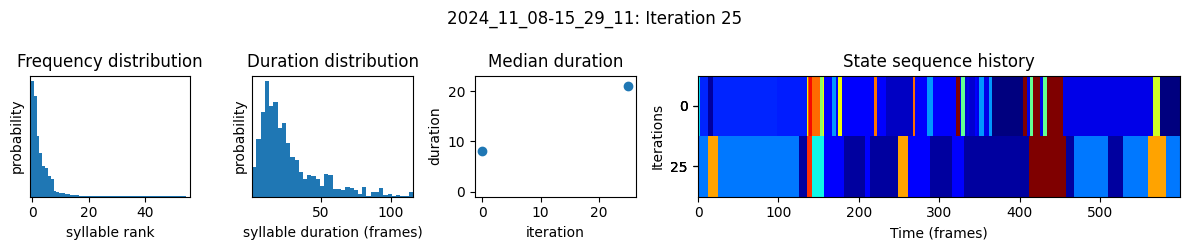

 33%|███████████▎                      | 50/151 [00:23<00:40,  2.52it/s]

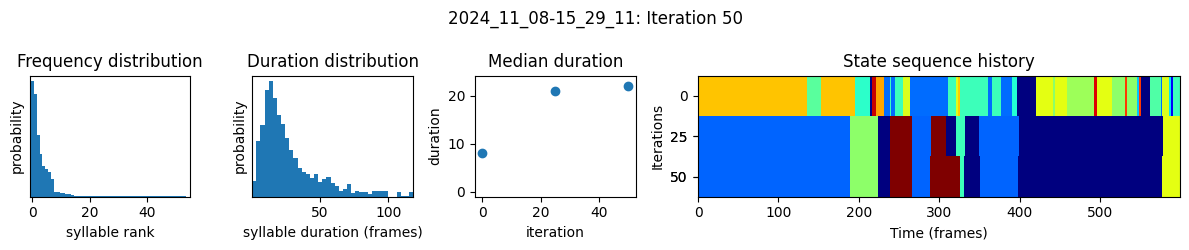

 50%|████████████████▉                 | 75/151 [00:33<00:30,  2.48it/s]

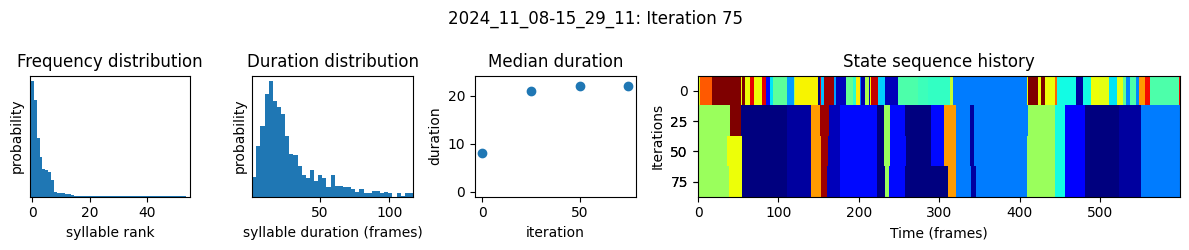

 66%|█████████████████████▊           | 100/151 [00:44<00:20,  2.51it/s]

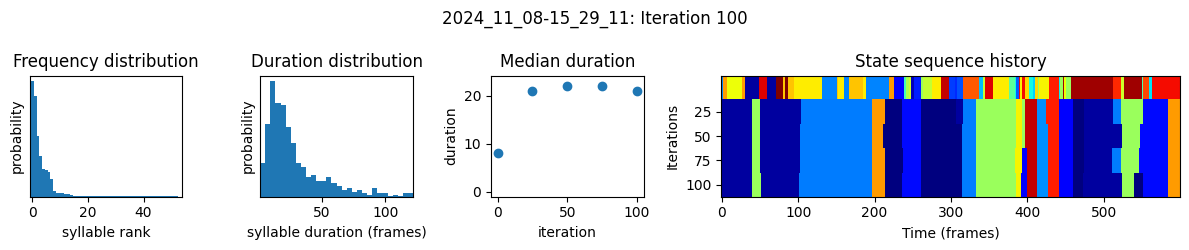

 83%|███████████████████████████▎     | 125/151 [00:55<00:10,  2.52it/s]

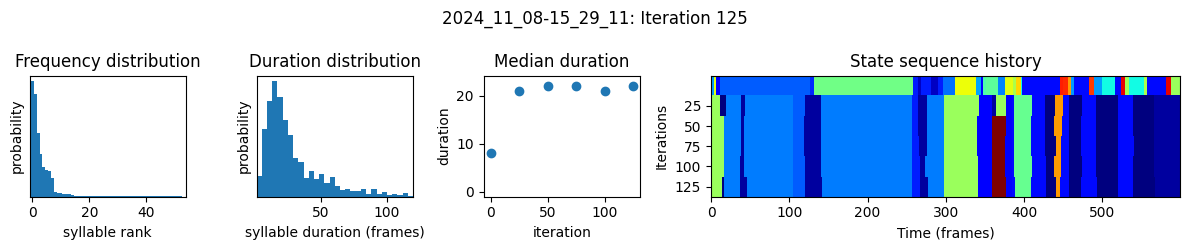

 99%|████████████████████████████████▊| 150/151 [01:05<00:00,  2.53it/s]

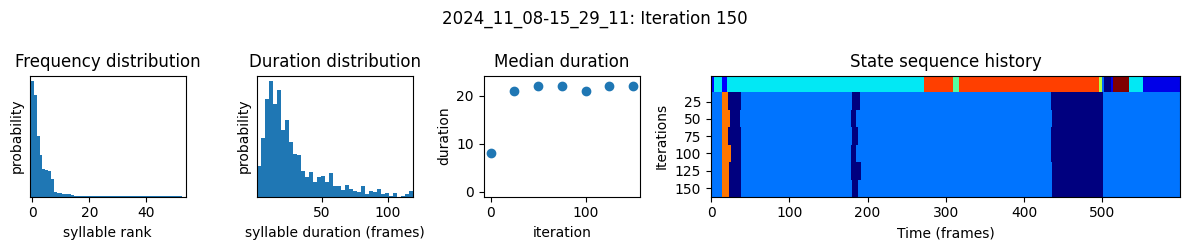

100%|█████████████████████████████████| 151/151 [01:06<00:00,  2.27it/s]


In [43]:
### Fit.

num_ar_iters = 150
model, model_name = kpms.fit_model(model, data, metadata, project_dir, ar_only=True, num_iters=num_ar_iters, location_aware=True)

## 5. Model fitting (SLDS full model)

Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_2
9_11


  5%|█▋                                | 25/501 [01:24<22:20,  2.82s/it]

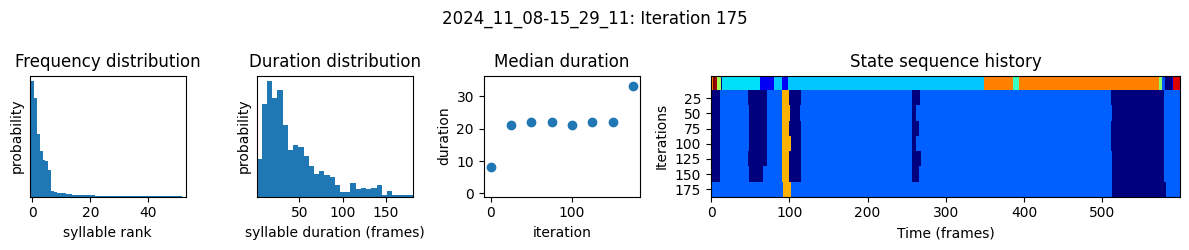

 10%|███▍                              | 50/501 [02:36<20:45,  2.76s/it]

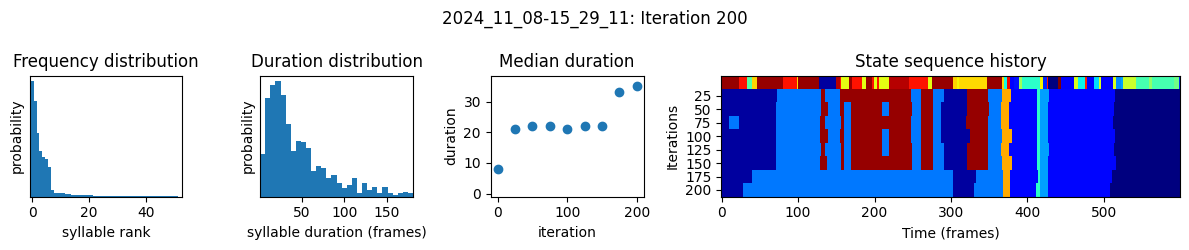

 15%|█████                             | 75/501 [03:45<19:22,  2.73s/it]

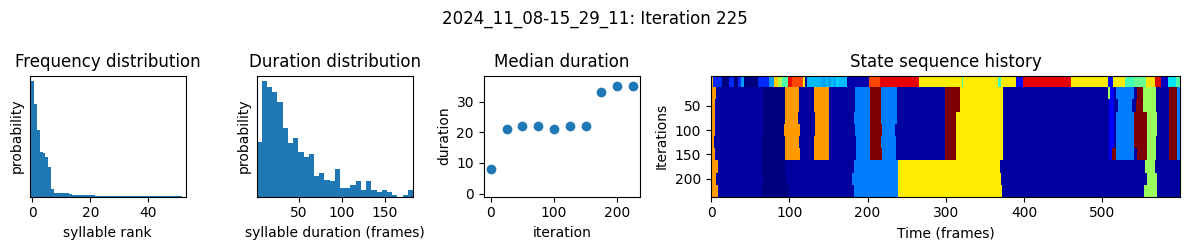

 20%|██████▌                          | 100/501 [04:55<18:48,  2.81s/it]

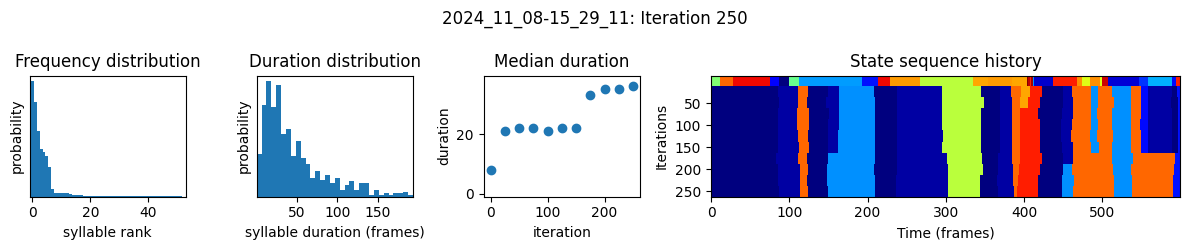

 25%|████████▏                        | 125/501 [06:05<17:12,  2.75s/it]

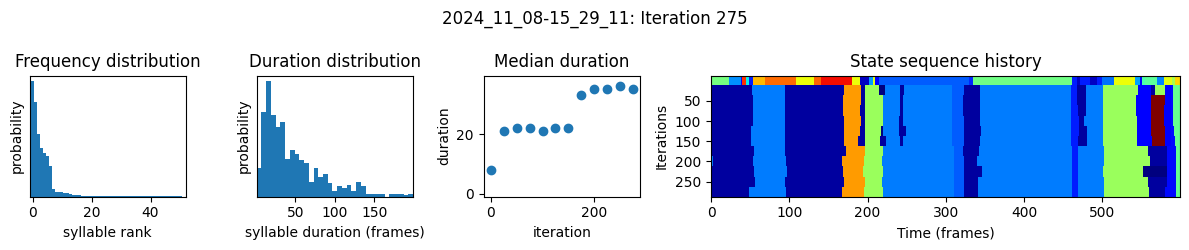

 30%|█████████▉                       | 150/501 [07:15<16:08,  2.76s/it]

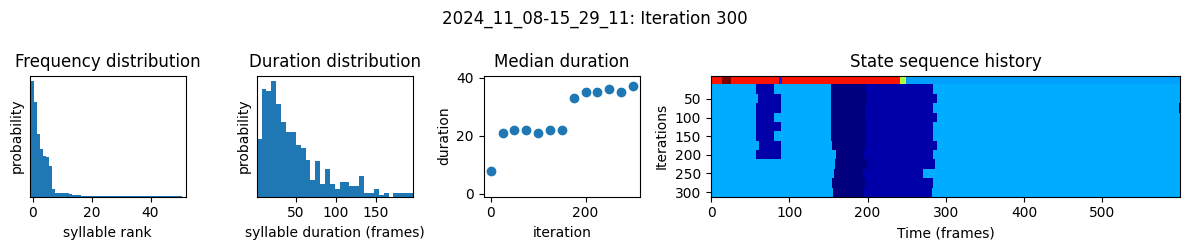

 35%|███████████▌                     | 175/501 [08:25<14:48,  2.73s/it]

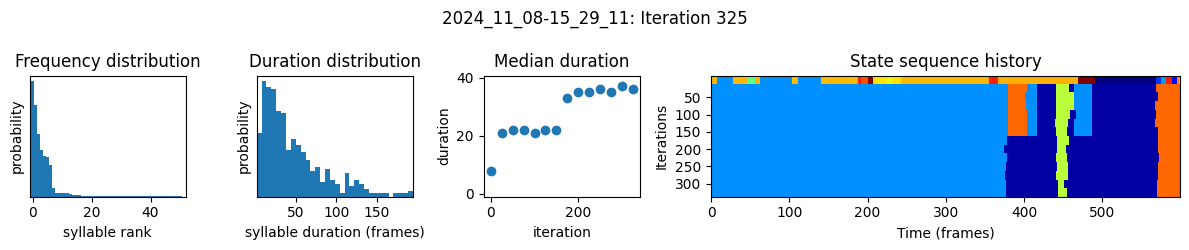

 40%|█████████████▏                   | 200/501 [09:34<13:58,  2.79s/it]

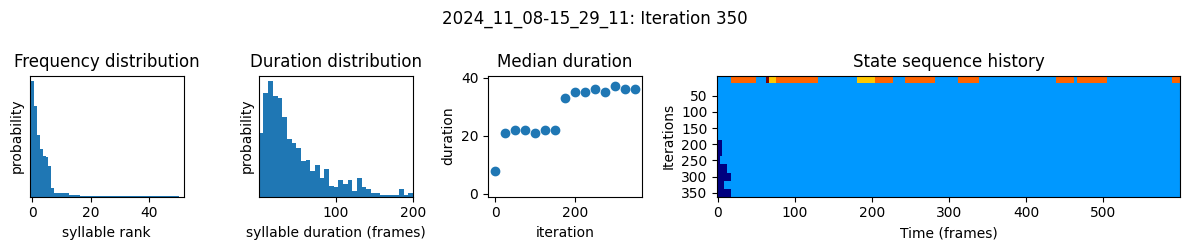

 45%|██████████████▊                  | 225/501 [10:42<12:25,  2.70s/it]

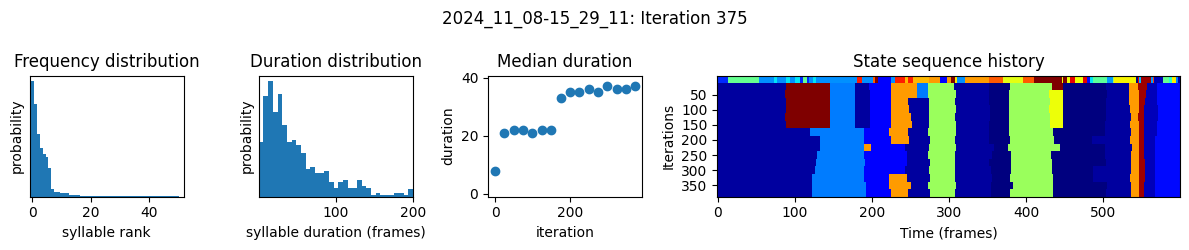

 50%|████████████████▍                | 250/501 [11:51<11:31,  2.75s/it]

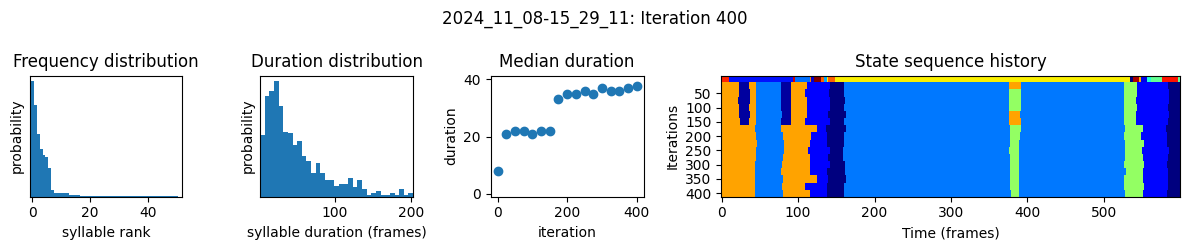

 55%|██████████████████               | 275/501 [13:02<10:33,  2.80s/it]

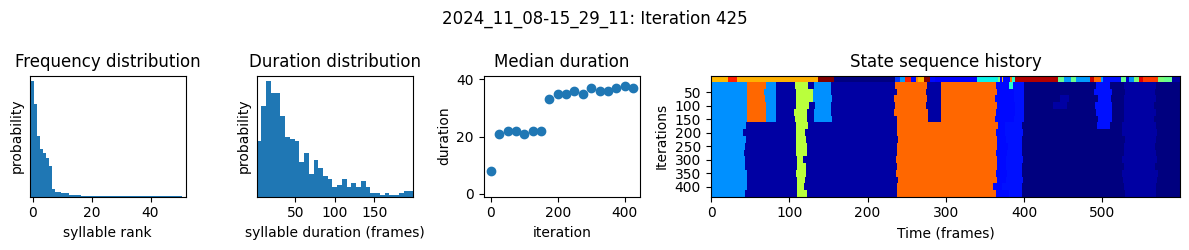

 60%|███████████████████▊             | 300/501 [14:12<09:16,  2.77s/it]

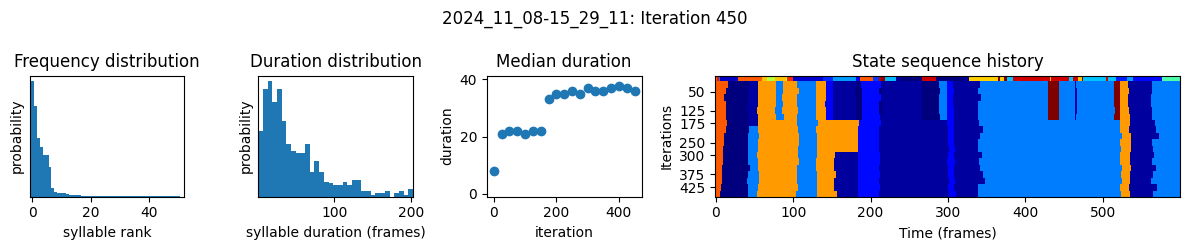

 65%|█████████████████████▍           | 325/501 [15:23<08:12,  2.80s/it]

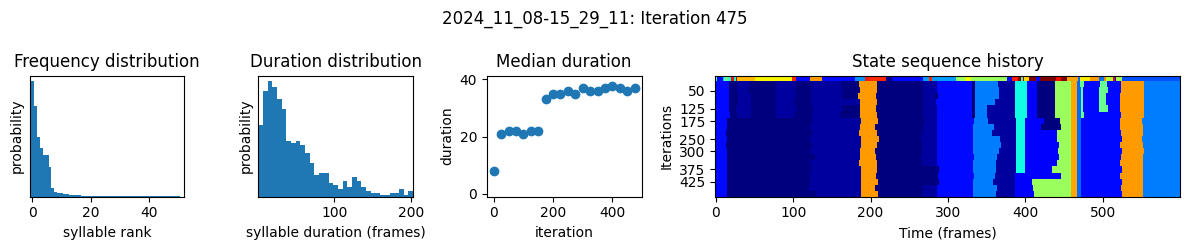

 70%|███████████████████████          | 350/501 [16:32<06:53,  2.74s/it]

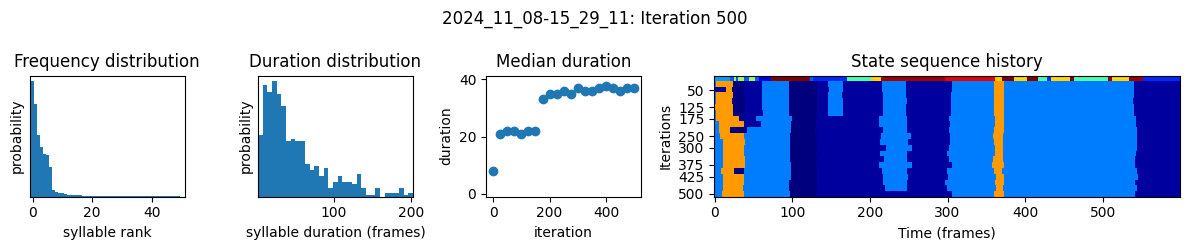

 75%|████████████████████████▋        | 375/501 [17:42<05:49,  2.78s/it]

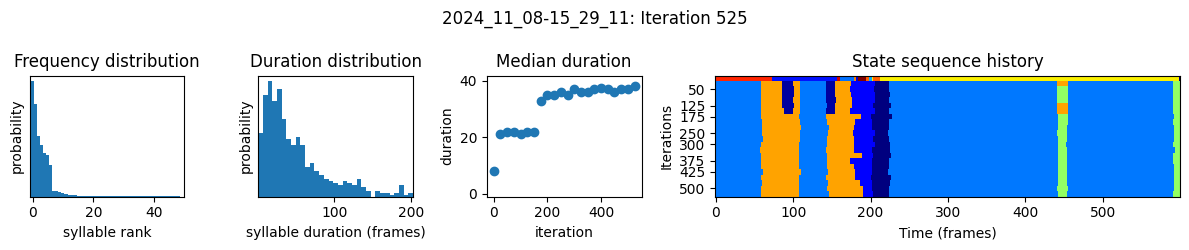

 80%|██████████████████████████▎      | 400/501 [18:51<04:29,  2.67s/it]

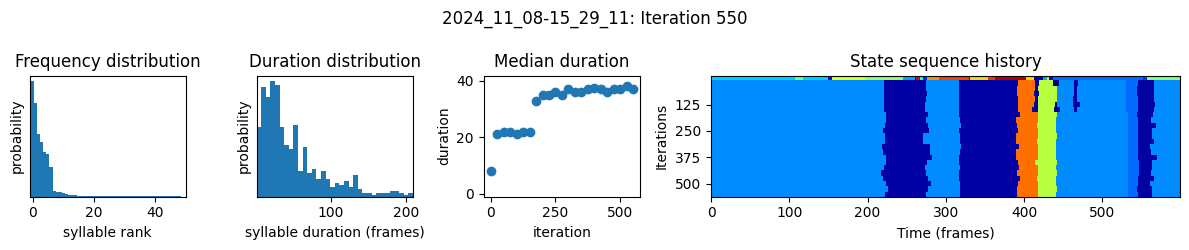

 85%|███████████████████████████▉     | 425/501 [19:59<03:23,  2.68s/it]

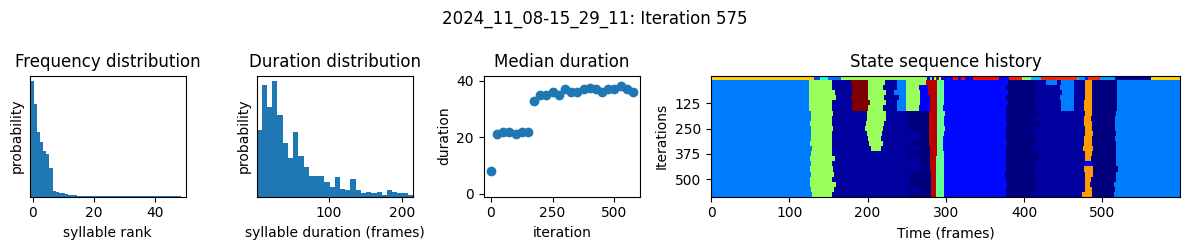

 90%|█████████████████████████████▋   | 450/501 [21:12<02:26,  2.87s/it]

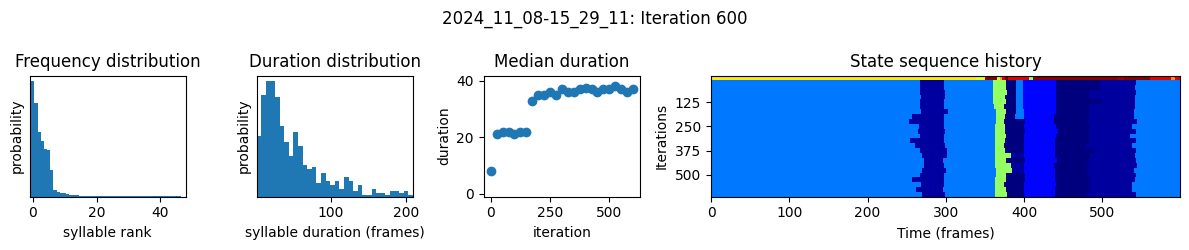

 95%|███████████████████████████████▎ | 475/501 [22:21<01:09,  2.67s/it]

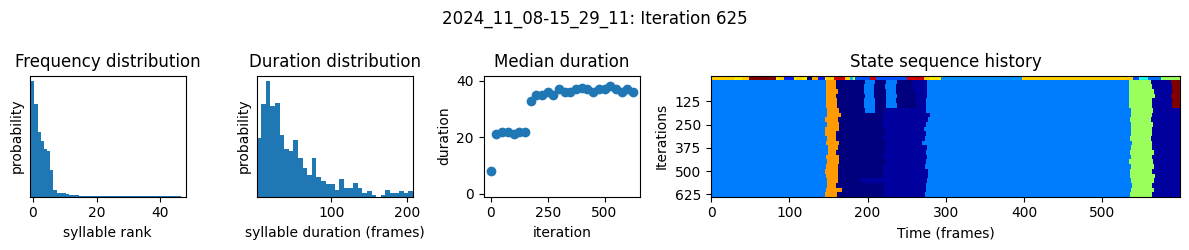

100%|████████████████████████████████▉| 500/501 [23:29<00:02,  2.69s/it]

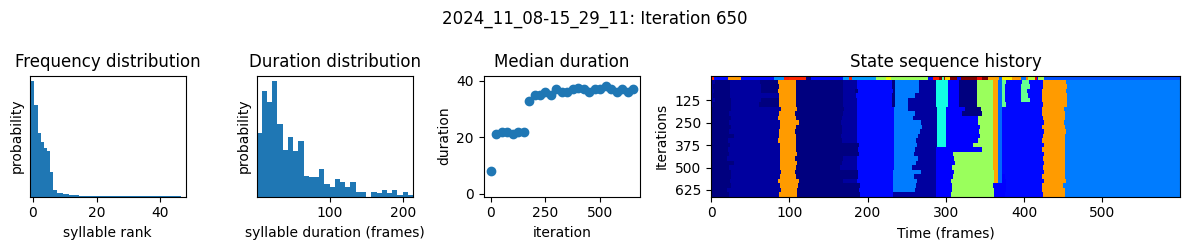

100%|█████████████████████████████████| 501/501 [23:32<00:00,  2.82s/it]


In [44]:
### Load model and checkpoints.

model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name, iteration=num_ar_iters)
model = kpms.update_hypparams(model, kappa=1e10) # NOTE: kappa for the AR-HMM should be larger than for SLDS for syllable length to remain consistent.

### Run SLDS model.

SLDS_iters = 500
model = kpms.fit_model(model, data, metadata, project_dir, model_name, ar_only=False, start_iter=current_iter, num_iters=current_iter + SLDS_iters, location_aware=True)[0]

## 6. Visualizations

In [46]:
### Get model results.

# Load the most recent model checkpoint.
# model_name = "2024_11_07-11_16_41" # From the KPMS file.
model_name = "2024_11_08-15_29_11"
model, data, metadata, current_iter = kpms.load_checkpoint(project_dir, model_name)

# Extract results.
results = kpms.extract_results(model, metadata, project_dir, model_name)

Saved results to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-0
9-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\res
ults.h5


In [ ]:
### Grid movies (no background video).

results = kpms.load_results(project_dir, model_name)
kpms.generate_grid_movies(
   results,
   project_dir,
   model_name,
   coordinates=coordinates,
   keypoints_only=True,
   keypoints_scale=1,
   use_dims=[0,1], # controls projection plane
   min_frequency=0.0,
   **config());

Writing grid movies to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_13-43-44)-SleapTrain_Bl6SW_2_test_project\2024_11_07-11_16_41\grid_movies
Using window size of 144 pixels


Generating grid movies: 100%|█████████████| 7/7 [00:20<00:00,  2.88s/it]


In [47]:
### Grid movies (with top down video background).

coordinates_2D, _, _ = kpms.load_keypoints(TRACKS_FILEPATH, "sleap") # Load original 2D tracks.
coordinates_2D_key = list(coordinates_2D.keys())[0]
coordinates_2D[CAMERA_VIDEO_FILENAME] = coordinates_2D.pop(coordinates_2D_key) # Rename the key to match the 3D tracks.
video_paths = kpms.find_matching_videos(coordinates_2D.keys(), CAMERA_VIDEO_FILEPATH, as_dict=True)

# Change keys for coordinates_2D and video_paths to match name in results dict.
results_key = list(results.keys())[0]
coordinates_2D[results_key] = coordinates_2D.pop(CAMERA_VIDEO_FILENAME)
video_paths[results_key] = video_paths.pop(CAMERA_VIDEO_FILENAME)

# centroids, headings = results[results_key]["centroid"], results[results_key]["heading"]
centroids, headings = kpms.get_centroids_headings(coordinates_2D, **config())

# Make the grid movies.
kpms.generate_grid_movies(
   results,
   project_dir,
   model_name,
   video_paths=video_paths,
   coordinates=coordinates_2D,
   centroids=centroids,
   headings=headings,
   min_frequency=0.0,
   overlay_keypoints=True,
   fps=60,
   **config());

Loading keypoints: 100%|██████████████████| 1/1 [00:02<00:00,  2.68s/it]


Writing grid movies to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\grid_movies


c:\Users\bm9751\AppData\Local\miniconda3\envs\keypoint_moseq\lib\site-packages\keypoint_moseq\viz.py:1282: UserWarning:


Videos will be downscaled by a factor of 0.83 so that the grid movies
are under 1920 pixels. Use `max_video_size` to increase or decrease
this size limit.





Using window size of 384 pixels


Generating grid movies: 100%|█████████████| 7/7 [01:24<00:00, 12.08s/it]


Saving trajectory plots to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\trajectory_plots


Generating trajectory plots: 100%|████████| 6/6 [00:01<00:00,  4.37it/s]


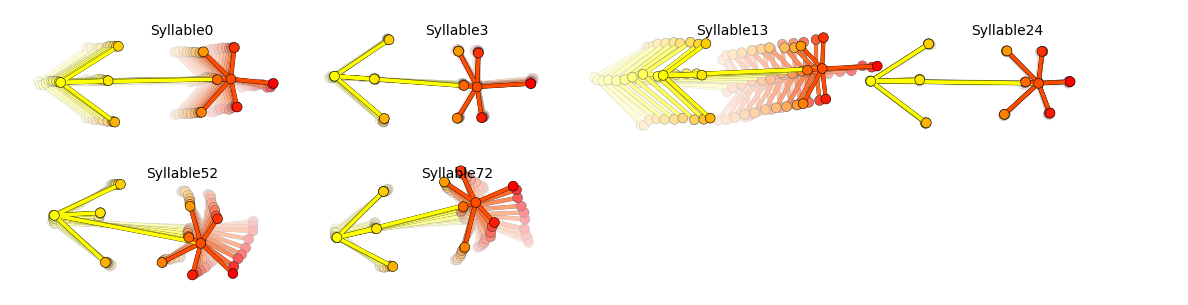

Generating trajectory plots: 100%|████████| 6/6 [00:01<00:00,  3.56it/s]


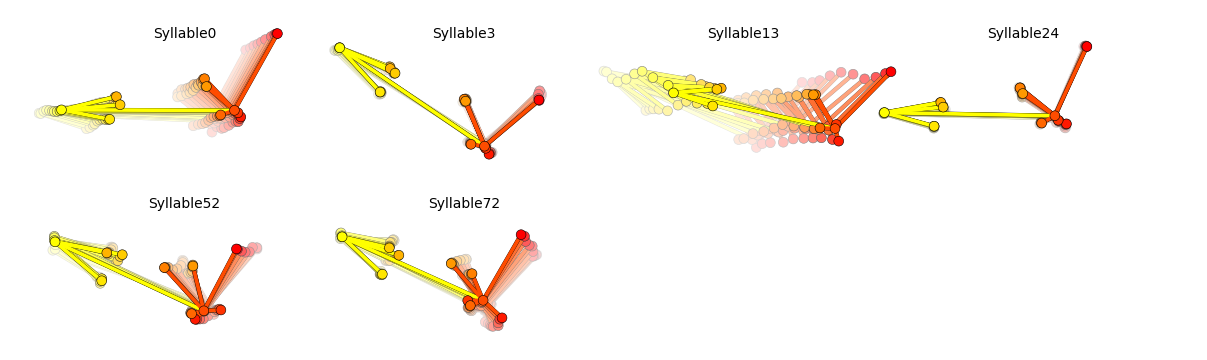

Saved interactive trajectories plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\trajectory_plots\all_trajectories.html


In [48]:
### Trajectory plots.

results = kpms.load_results(project_dir, model_name)
kpms.generate_trajectory_plots(coordinates, results, project_dir, model_name, min_frequency=0.0, **config())

Saving dendrogram plot to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\similarity_dendrogram


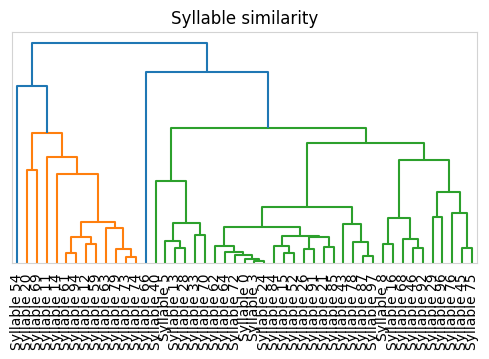

In [49]:
### Syllable similarity dendrogram.

kpms.plot_similarity_dendrogram(coordinates, results, project_dir, model_name, min_frequency=0.0, **config())

Group(s): default
Saved figure to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\figures\transition_matrices.png


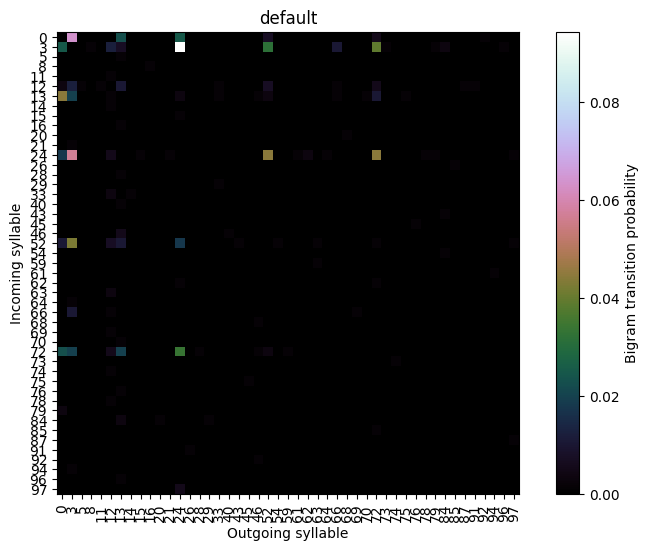

In [50]:
### Transition matrix.

normalize = "bigram" # Normalization method ("bigram", "rows" or "columns").

trans_mats, usages, groups, syll_include=kpms.generate_transition_matrices(
    project_dir, model_name, normalize=normalize,
    min_frequency=0.0 # minimum syllable frequency to include
)    

kpms.visualize_transition_bigram(
    project_dir, model_name, groups, trans_mats, syll_include, normalize=normalize, 
    show_syllable_names=True # label syllables by index (False) or index and name (True)
)

Saved figure to z:\Ben\Projects\StressDASert\Behavior\Scripts\(2024-09-25_14-00-35)-SleapTrain_Bl6SW_3_test_project\2024_11_08-15_29_11\figures\transition_graphs.png


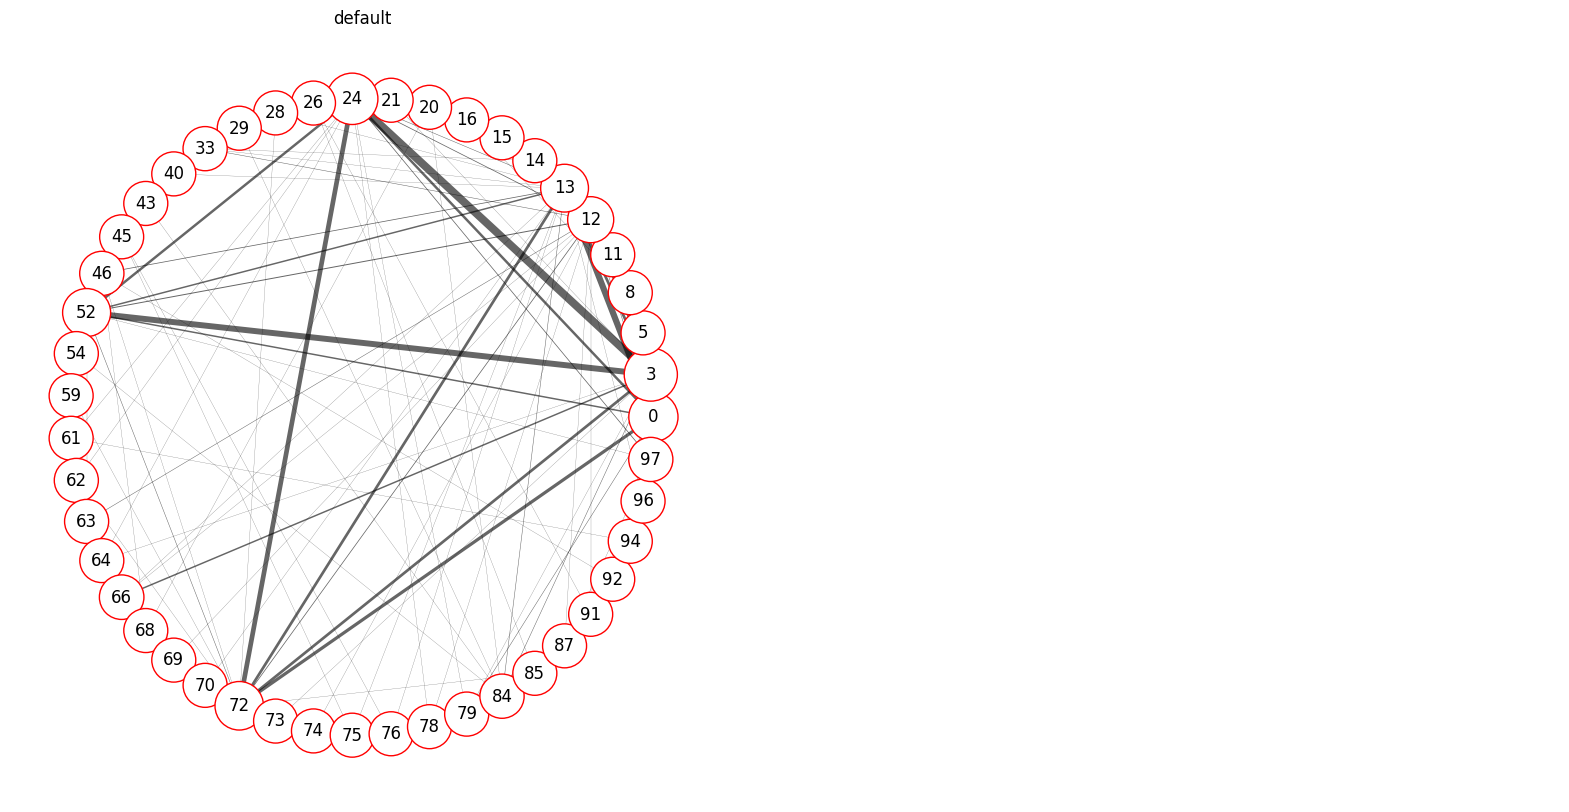

In [51]:
### Transition graph.

kpms.plot_transition_graph_group(
    project_dir, model_name, 
    groups, trans_mats, usages, syll_include, 
    layout="circular",        # transition graph layout ("circular" or "spring")
    show_syllable_names=False # label syllables by index (False) or index and name (True)
)

## 7. Syllable occupancy

Text(0.5, 1.0, 'Syllables')

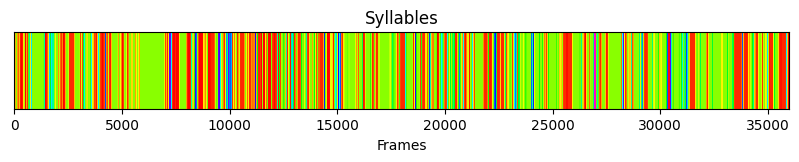

In [52]:
### Plot syllables for the video recording.

# Load results.
results = kpms.load_results(project_dir, model_name)
syllables = results["black_triangulated"]["syllable"]

# Make figure.
fig = plt.figure(figsize=(10, 1))
plt.imshow([syllables], aspect="auto", cmap="hsv")
plt.yticks([])
plt.xlabel("Frames")
plt.title("Syllables")

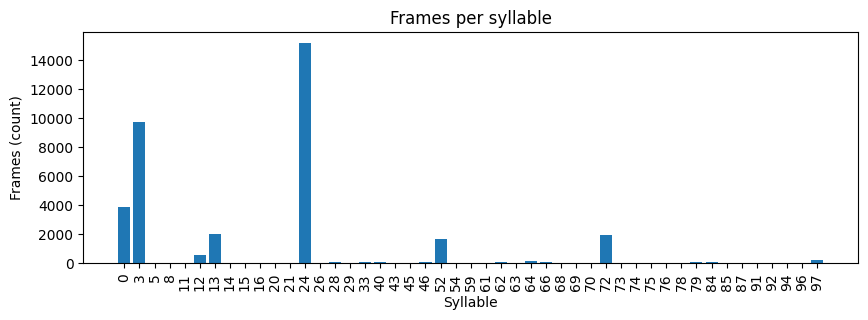

In [53]:
### Time spent in each syllable.

# Load results.
results = kpms.load_results(project_dir, model_name)
syllables = results["black_triangulated"]["syllable"]

syllable_names = np.unique(syllables)
frames_per_syllable = np.array([np.sum(syllables == s) for s in syllable_names])

# Make histogram for frames per syllable.
plt.figure(figsize=(10, 3))
plt.bar(np.arange(0, len(syllable_names), 1), frames_per_syllable)
plt.xlabel("Syllable")
plt.ylabel("Frames (count)")
plt.title("Frames per syllable")
plt.xticks(np.arange(0, len(syllable_names), 1), syllable_names, rotation=90);

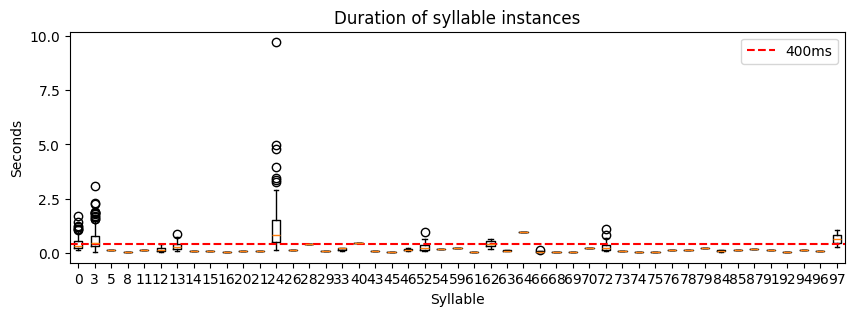

In [54]:
### Duration of each syllable.

# Load results.
results = kpms.load_results(project_dir, model_name)
syllables = results["black_triangulated"]["syllable"]

# Get number of frames per each contiguous instance of each syllable.
syllable_instances = {}
syllable_names = np.unique(syllables)
for syllable_name in syllable_names:
    syllable_instances[syllable_name] = [len(list(group)) for key, group in itertools.groupby(syllables) if key == syllable_name]

# Make histogram for frames per syllable.
fps = 120
frame_duration = 1 / fps
plt.figure(figsize=(10, 3))
plt.boxplot([syllable_instances[syllable_name] for syllable_name in syllable_names], labels=syllable_names)
plt.xlabel("Syllable")
plt.ylabel("Seconds")
plt.title("Duration of syllable instances")
max_frames = max([max(syllable_instances[syllable_name]) for syllable_name in syllable_names])
max_frames = np.ceil(max_frames / 100) * 100 # Round up to nearest 1000.
plt.yticks(np.linspace(0, max_frames, 5), (np.linspace(0, max_frames, 5) * frame_duration).round(2));
level_400ms = 0.4 / frame_duration
plt.axhline(level_400ms, color="red", linestyle="--", label="400ms")
plt.legend();

Loading keypoints: 100%|██████████████████| 1/1 [00:02<00:00,  2.96s/it]


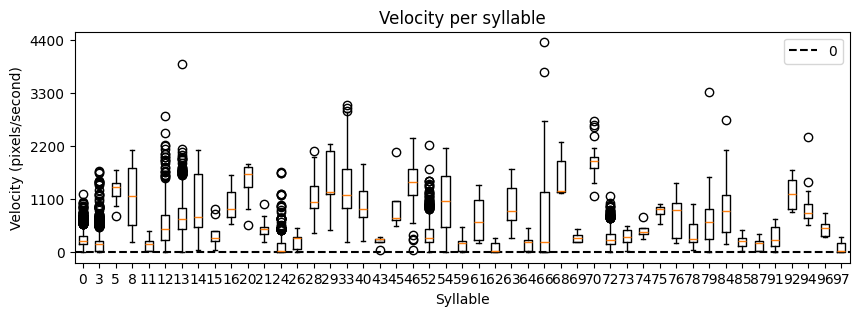

In [55]:
### Velocity per syllable.

# Load data.
coordinates_2D, _, _ = kpms.load_keypoints(TRACKS_FILEPATH, "sleap") # Load original 2D tracks.
coordinates_2D_key = list(coordinates_2D.keys())[0]
coordinates_2D[CAMERA_VIDEO_FILENAME] = coordinates_2D.pop(coordinates_2D_key) # Rename the key to match the 3D tracks.
video_paths = kpms.find_matching_videos(coordinates_2D.keys(), CAMERA_VIDEO_FILEPATH, as_dict=True)

# Change keys for coordinates_2D and video_paths to match name in results dict.
results_key = list(results.keys())[0]
coordinates_2D[results_key] = coordinates_2D.pop(CAMERA_VIDEO_FILENAME)
video_paths[results_key] = video_paths.pop(CAMERA_VIDEO_FILENAME)

# centroids, headings = results[results_key]["centroid"], results[results_key]["heading"]
centroids, headings = kpms.get_centroids_headings(coordinates_2D, **config())
centroids = centroids["black_triangulated"]

# Use centroids to get instantaneous velocity (euclidean distance / inter-frame interval between frames).DS_Store
fps = 120
frame_duration = 1 / fps
velocities = np.array([0] + [np.linalg.norm(centroids[i] - centroids[i - 1]) / frame_duration for i in range(1, len(centroids))])

# Get syllables.
syllables = results["black_triangulated"]["syllable"]
syllable_names = np.unique(syllables)

# Get velocity for each syllable.
syllable_velocities = {}
for syllable_name in syllable_names:
    syllable_velocities[syllable_name] = velocities[syllables == syllable_name]

# Make boxplot for velocity per syllable.
plt.figure(figsize=(10, 3))
plt.boxplot([syllable_velocities[syllable_name] for syllable_name in syllable_names], labels=syllable_names)
plt.xlabel("Syllable")
plt.ylabel("Velocity (pixels/second)")
plt.title("Velocity per syllable")
max_velocity = max([max(syllable_velocities[syllable_name]) for syllable_name in syllable_names])
max_velocity = np.ceil(max_velocity / 100) * 100 # Round up to nearest 1000.
plt.yticks(np.linspace(0, max_velocity, 5), np.linspace(0, max_velocity, 5).astype(int));
plt.axhline(0, color="black", linestyle="--", label="0")
plt.legend();


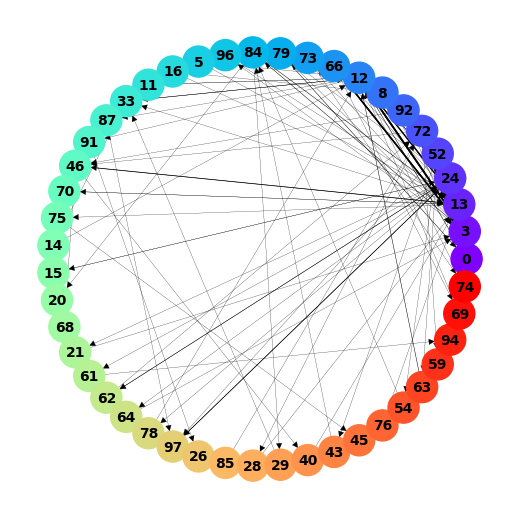

In [56]:
### Make syllables occupancy animation.

# Get transition matrix.
transition_matrix = np.array(trans_mats)[0, ...]
syllable_labels = syll_include

# Make graph figure of the syllables with edge weights as transition probabilities.
G = nx.DiGraph()
for i, row in enumerate(transition_matrix):
    for j, prob in enumerate(row):
        if prob > 0:
            G.add_edge(syllable_labels[i], syllable_labels[j], weight=prob)

# Make figure.
fig = plt.figure(figsize=(5, 5))
pos = nx.circular_layout(G)

# Generate a color map for the nodes
colors = plt.cm.rainbow(np.linspace(0, 1, len(G.nodes())))

# Get edge weights for thickness
edges = G.edges(data=True)
weights = [edge[2]["weight"] * 100 for edge in edges]  # Multiply by a factor to make the differences more visible

# Draw the graph
nx.draw(G, pos, with_labels=True, node_size=500, node_color=colors, font_size=10, font_weight="bold", edge_color="black", width=weights)


In [114]:
### Make syllable occupancy animation.

# Create the directed graph with edge weights as transition probabilities.
G = nx.DiGraph()
for i, row in enumerate(transition_matrix):
    for j, prob in enumerate(row):
        if prob > 0:
            G.add_edge(syllable_labels[i], syllable_labels[j], weight=prob)

# Position the nodes in a circular layout.
pos = nx.circular_layout(G)

# Get edge weights for line thickness.
edge_thickness_scalar = 100
edges = G.edges(data=True)
weights = [edge[2]["weight"] * edge_thickness_scalar for edge in edges]

# Prepare the figure.
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
ax.axis("off")

# Get the size of the figure in pixels.
fig.canvas.draw()
width, height = fig.canvas.get_width_height()
width = int(width)
height = int(height)

# Set up the OpenCV VideoWriter.
fps = 120.0
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
video = cv2.VideoWriter("../Figures/syllable_occupancy.mp4", fourcc, fps, (width, height))

# Make a color vector: one color for each syllable.
colors = plt.cm.rainbow(np.linspace(0, 1, len(G.nodes())))

# List of nodes.
node_list = list(G.nodes())

# Draw edges and labels once (they don't change).
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="black", width=weights)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")

# Initialize node colors (all grey).
node_colors = ["grey"] * len(node_list)

# Draw nodes once and get the node collection.
node_collection = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=300)

# Generate frames and write to the video.
for frame in trange(len(syllables), desc="Making syllable occupancy video"):
    # Update node colors.
    node_colors = ["grey"] * len(node_list)
    current_syllable = syllables[frame]
    if current_syllable in node_list:
        idx = node_list.index(current_syllable)
        node_colors[idx] = colors[idx]

    # Update the colors of the nodes in the collection.
    node_collection.set_color(node_colors)

    # Render the plot to a numpy array.
    fig.canvas.draw()
    img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
    img = img.reshape((height, width, 3))

    # Convert RGB to BGR for OpenCV.
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    # Write the frame to the video.
    video.write(img)

# Release the VideoWriter and close the figure.
video.release()
plt.close(fig)

Making syllable occupancy video:   0%|          | 0/36001 [00:00<?, ?it/s]C:\Users\bm9751\AppData\Local\Temp\ipykernel_49584\1307831589.py:63: MatplotlibDeprecationWarning:

The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed two minor releases later. Use buffer_rgba instead.

Making syllable occupancy video: 100%|██████████| 36001/36001 [43:21<00:00, 13.84it/s]


## 8. KPMS training on multiple sessions

In [9]:
### Get paths to the session directories.

# Get session paths.
experiment_directory = "Z:/Ben/Projects/StressDASert/Behavior/Data/SleapTrainVideos/2024-09-27"
experiment_name = experiment_directory.split("/")[-1]
session_directories = [os.path.join(experiment_directory, session) for session in os.listdir(experiment_directory) if "calibration" not in session and ".DS_Store" not in session]

# Verify they exist.
for session_directory in session_directories:
    assert os.path.exists(session_directory), f"Session directory does not exist: {session_directory}"
session_directories.sort()

In [10]:
### Create experiment project.

# Make experiment KPMS directory.
experiment_project_dirname = f"{experiment_name}_KPMS_project"
experiment_project_filepath = os.path.join(os.getcwd(), experiment_project_dirname)
os.makedirs(experiment_project_filepath, exist_ok=True)

# Make experiment config file.
config = lambda: kpms.load_config(experiment_project_filepath)

Setting up project for session 1.


Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  4.28it/s]


>=90.0% of variance exlained by 7 components.
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\2024-09-27_KPMS_project\session_0\2024_11_15-15_01_45


 17%|█████▋                            | 25/151 [00:10<00:49,  2.52it/s]

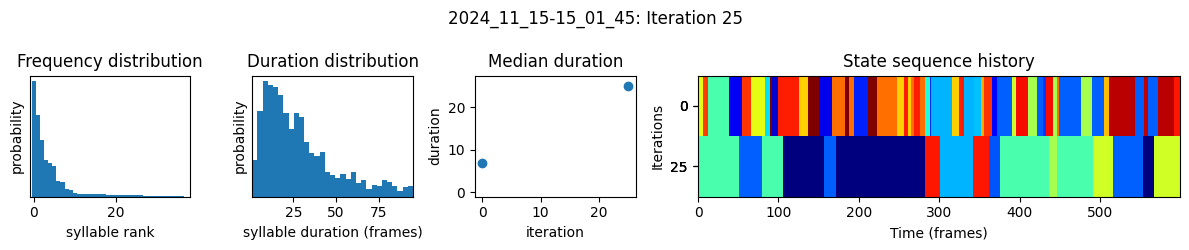

 33%|███████████▎                      | 50/151 [00:20<00:39,  2.54it/s]

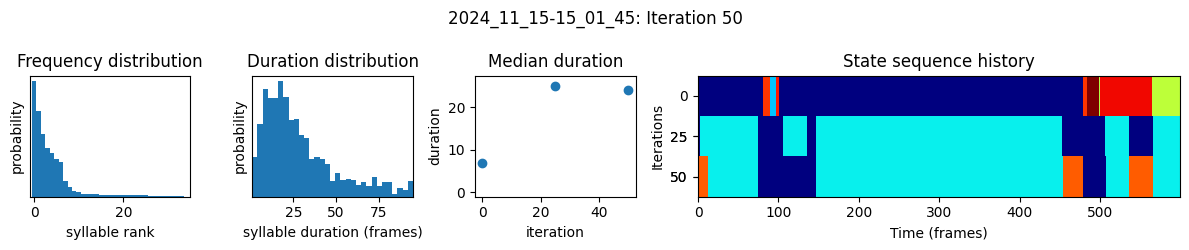

 50%|████████████████▉                 | 75/151 [00:30<00:30,  2.49it/s]

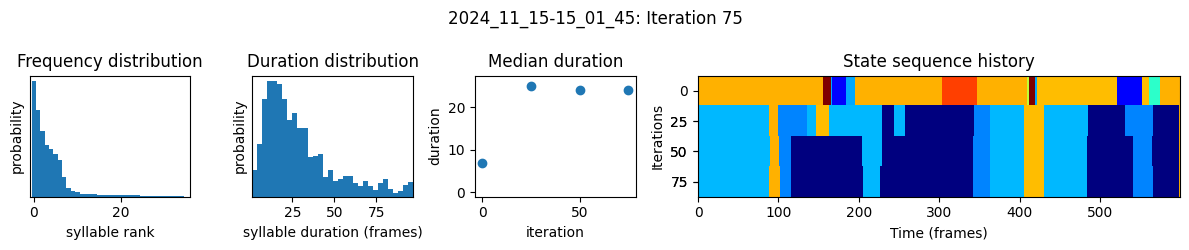

 66%|█████████████████████▊           | 100/151 [00:41<00:20,  2.50it/s]

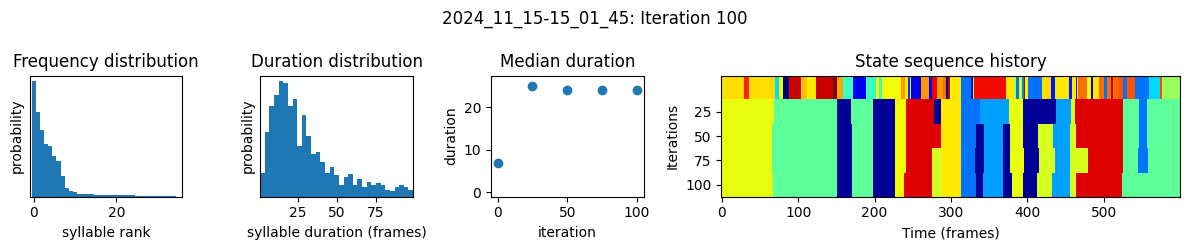

 83%|███████████████████████████▎     | 125/151 [00:51<00:10,  2.53it/s]

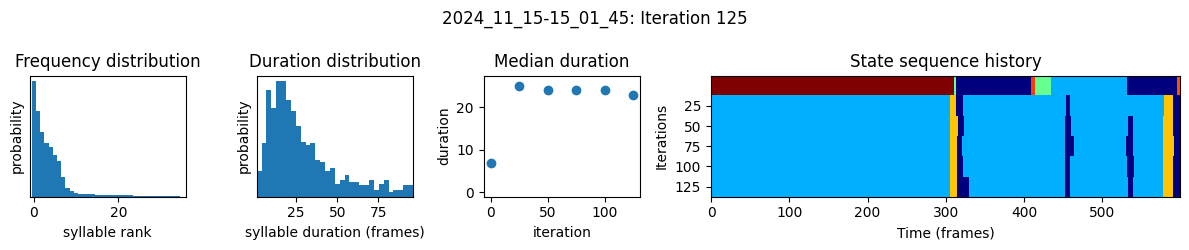

 99%|████████████████████████████████▊| 150/151 [01:02<00:00,  2.50it/s]

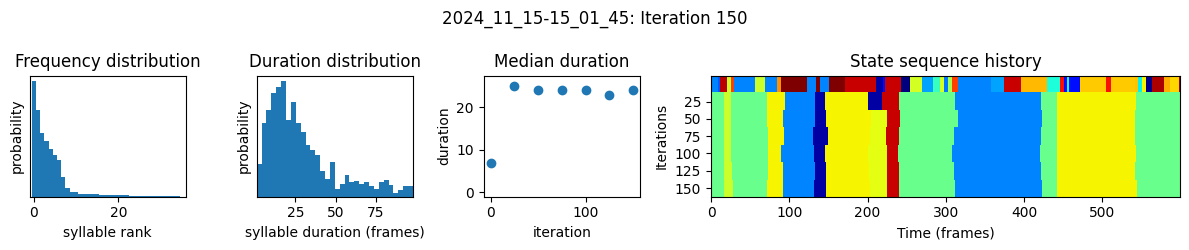

100%|█████████████████████████████████| 151/151 [01:03<00:00,  2.39it/s]


Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\2024-09-27_KPMS_project\session_0\2024_11_15-15_01_45


  8%|██▊                               | 25/301 [01:06<12:21,  2.69s/it]

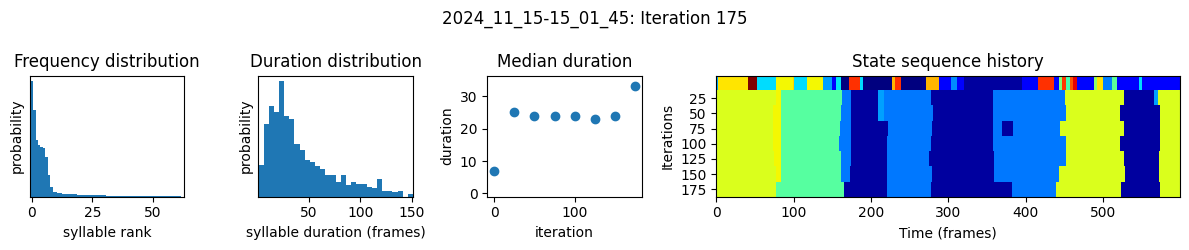

 17%|█████▋                            | 50/301 [02:13<11:06,  2.65s/it]

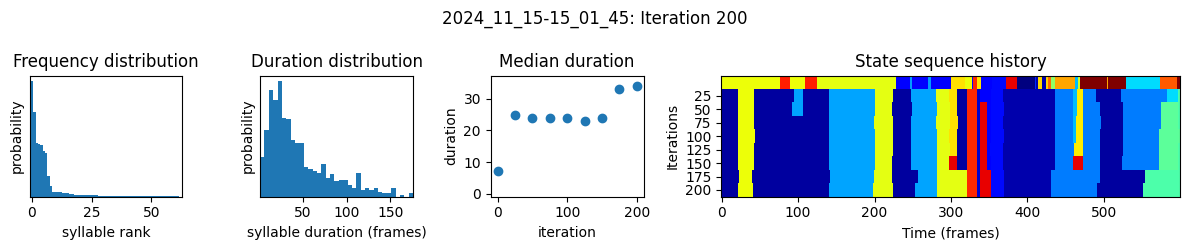

 25%|████████▍                         | 75/301 [03:21<10:06,  2.69s/it]

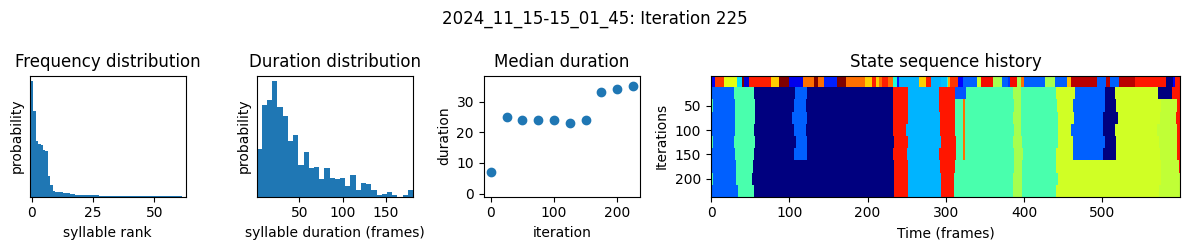

 33%|██████████▉                      | 100/301 [04:28<08:52,  2.65s/it]

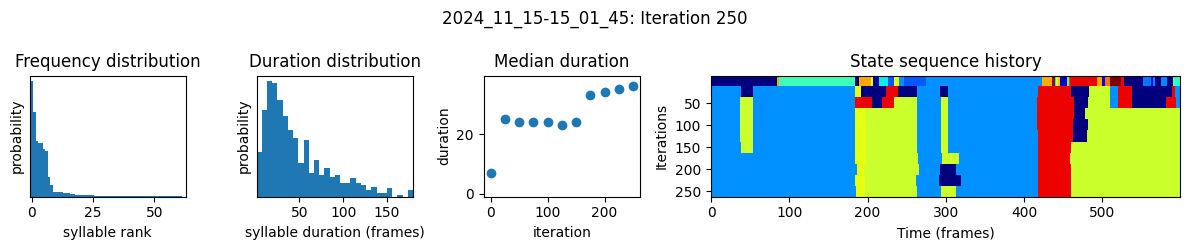

 42%|█████████████▋                   | 125/301 [05:35<07:59,  2.72s/it]

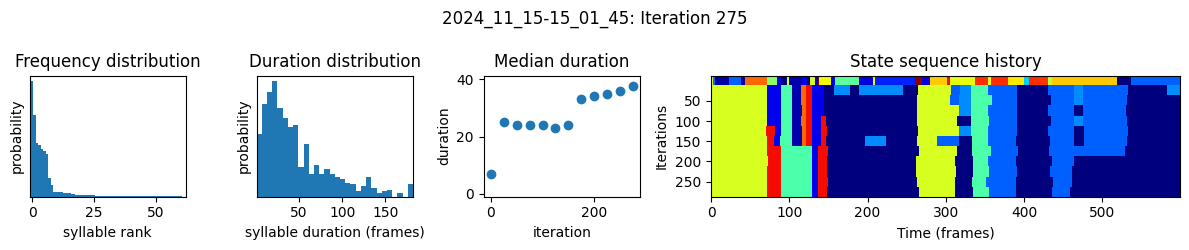

 50%|████████████████▍                | 150/301 [06:43<06:38,  2.64s/it]

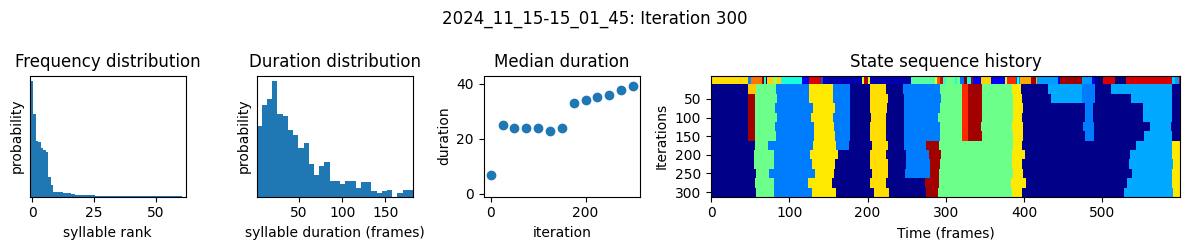

 58%|███████████████████▏             | 175/301 [07:49<05:29,  2.62s/it]

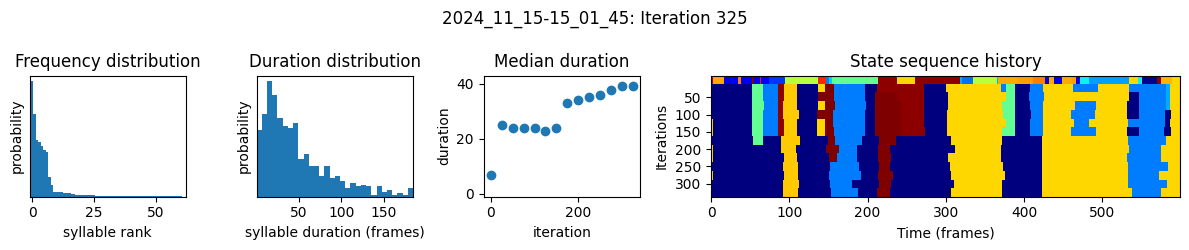

 66%|█████████████████████▉           | 200/301 [08:56<04:31,  2.68s/it]

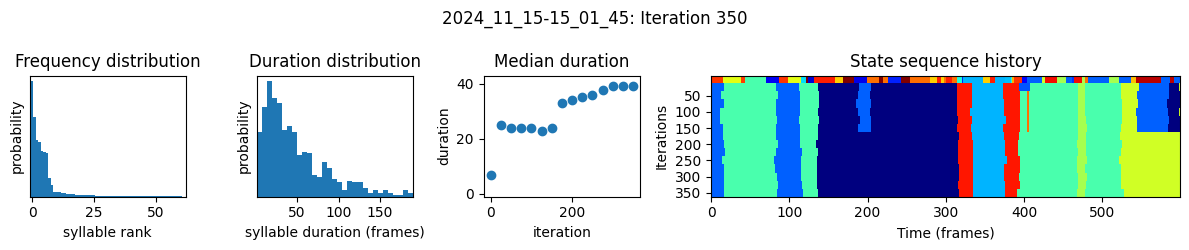

 75%|████████████████████████▋        | 225/301 [10:03<03:21,  2.65s/it]

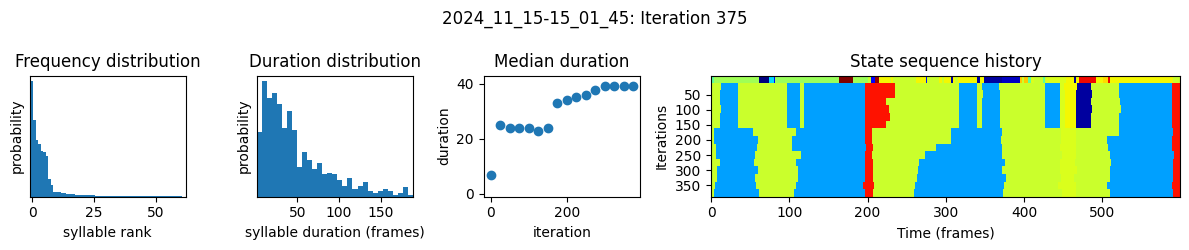

 83%|███████████████████████████▍     | 250/301 [11:10<02:15,  2.66s/it]

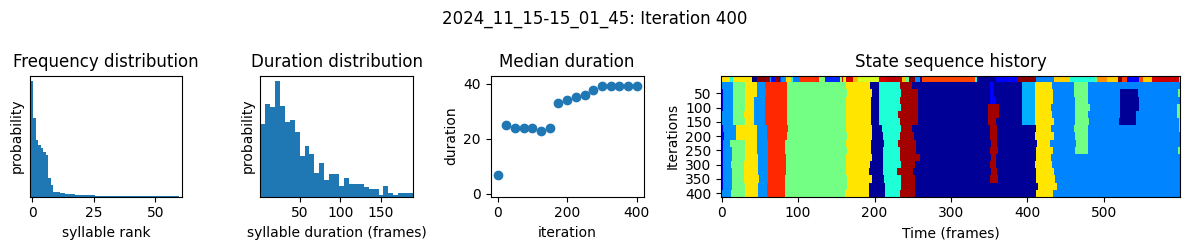

 91%|██████████████████████████████▏  | 275/301 [12:17<01:08,  2.64s/it]

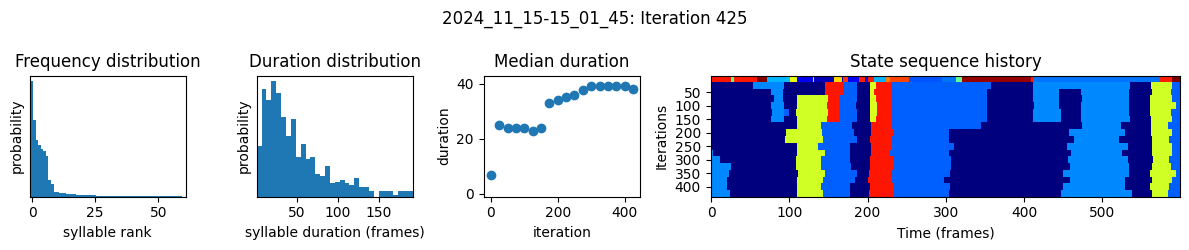

100%|████████████████████████████████▉| 300/301 [13:23<00:02,  2.63s/it]

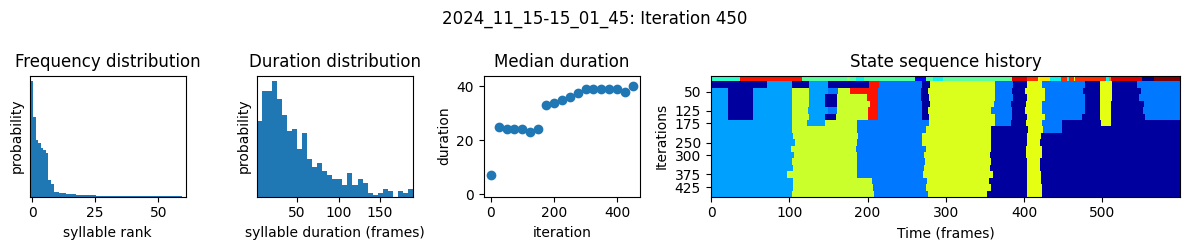

100%|█████████████████████████████████| 301/301 [13:27<00:00,  2.68s/it]


Setting up project for session 2.


Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  1.50it/s]


>=90.0% of variance exlained by 5 components.
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\2024-09-27_KPMS_project\session_1\2024_11_15-15_16_21


  8%|██▊                               | 25/301 [01:05<12:08,  2.64s/it]

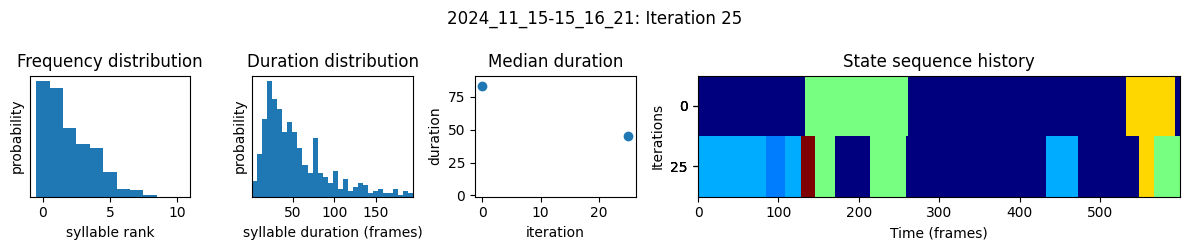

 17%|█████▋                            | 50/301 [02:11<10:59,  2.63s/it]

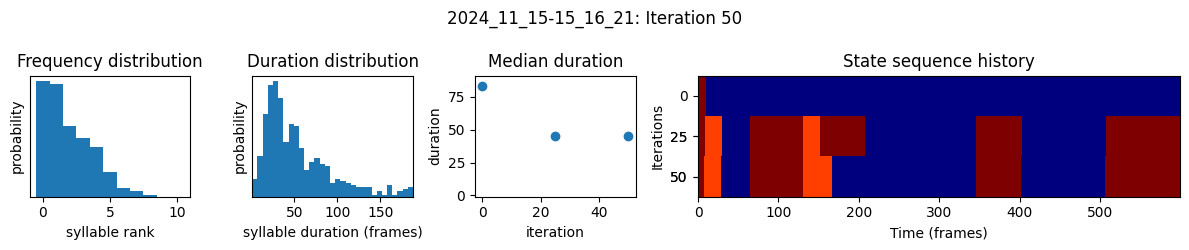

 25%|████████▍                         | 75/301 [03:18<10:09,  2.70s/it]

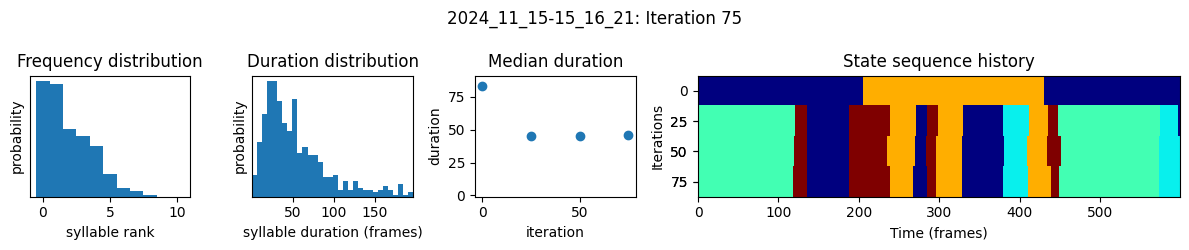

 33%|██████████▉                      | 100/301 [04:25<08:51,  2.64s/it]

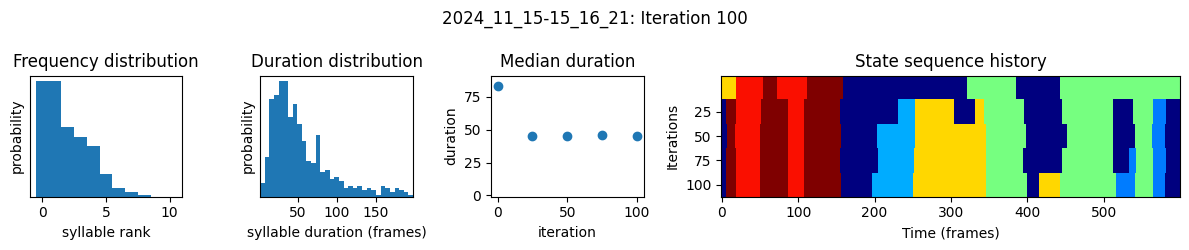

 42%|█████████████▋                   | 125/301 [05:32<07:53,  2.69s/it]

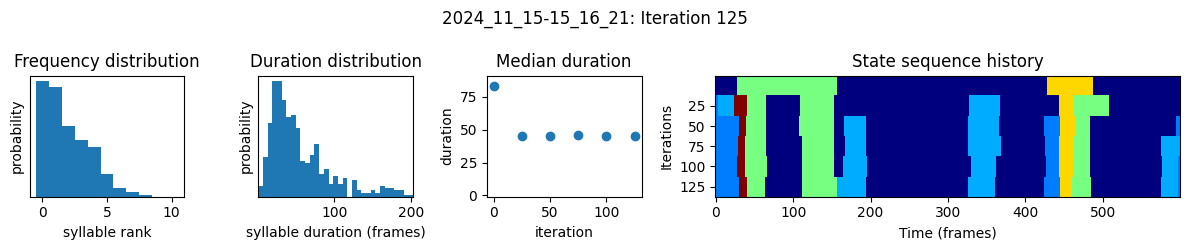

 50%|████████████████▍                | 150/301 [06:39<06:40,  2.65s/it]

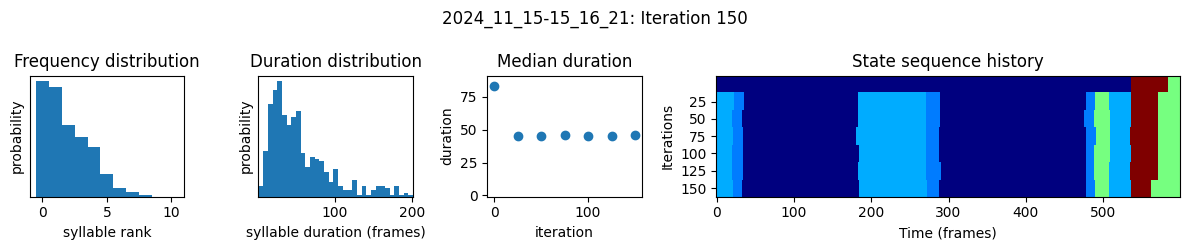

 58%|███████████████████▏             | 175/301 [07:47<05:39,  2.70s/it]

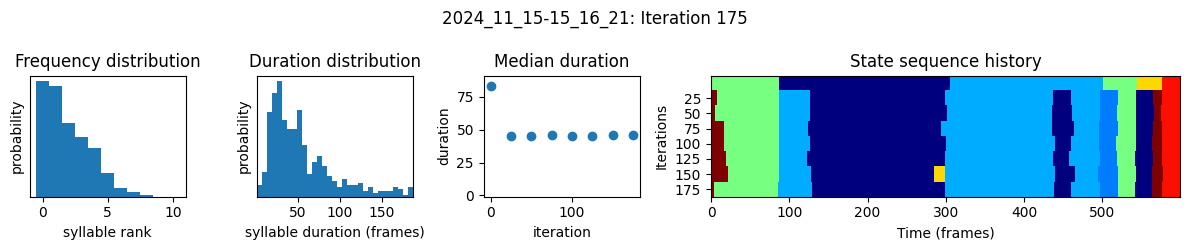

 66%|█████████████████████▉           | 200/301 [08:54<04:26,  2.64s/it]

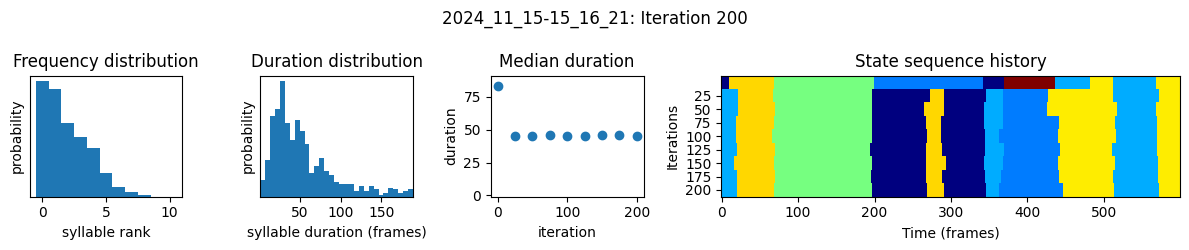

 75%|████████████████████████▋        | 225/301 [10:00<03:20,  2.63s/it]

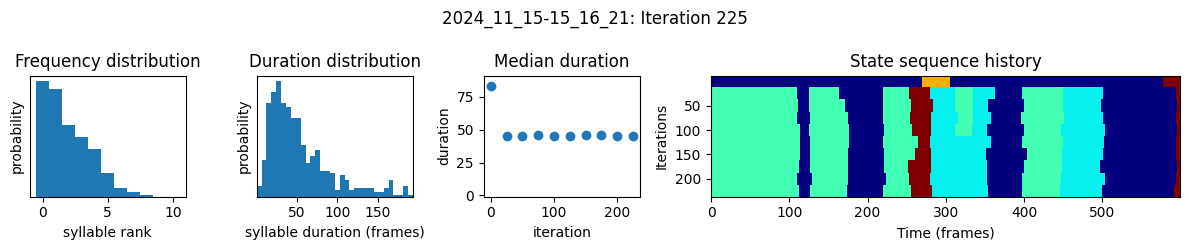

 83%|███████████████████████████▍     | 250/301 [11:07<02:16,  2.67s/it]

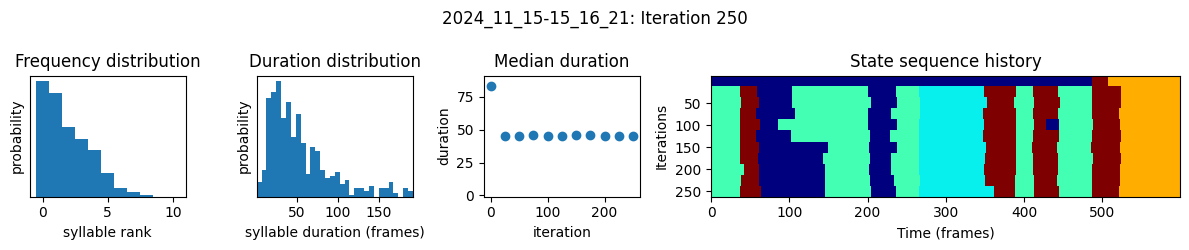

 91%|██████████████████████████████▏  | 275/301 [12:14<01:08,  2.65s/it]

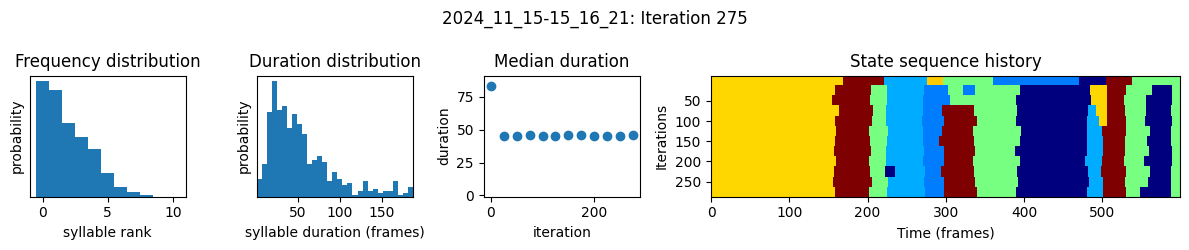

100%|████████████████████████████████▉| 300/301 [13:21<00:02,  2.64s/it]

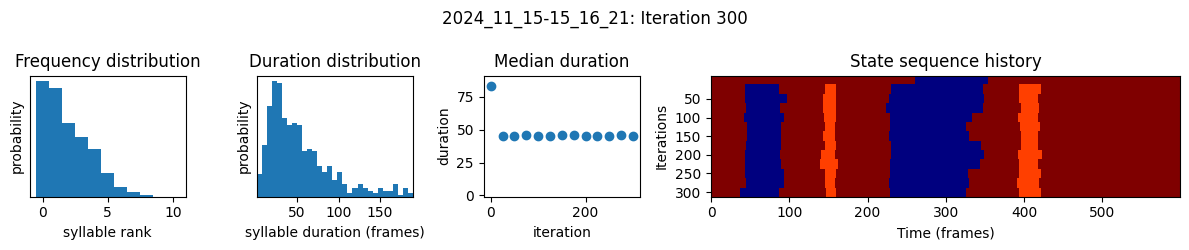

100%|█████████████████████████████████| 301/301 [13:24<00:00,  2.67s/it]


Setting up project for session 3.


Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  1.25it/s]


>=90.0% of variance exlained by 5 components.
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\2024-09-27_KPMS_project\session_2\2024_11_15-15_29_50


  8%|██▊                               | 25/301 [01:06<12:19,  2.68s/it]

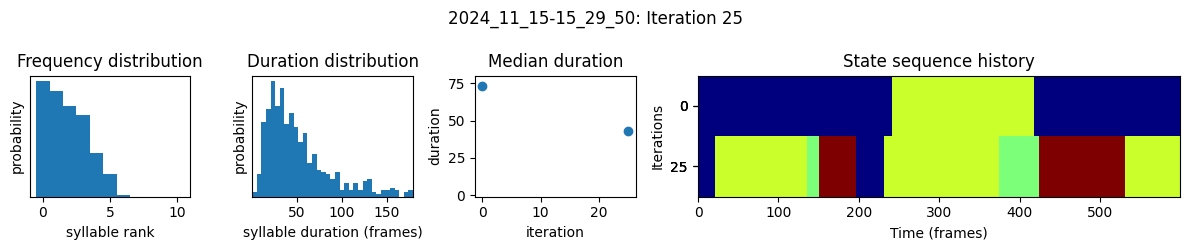

 17%|█████▋                            | 50/301 [02:14<11:23,  2.72s/it]

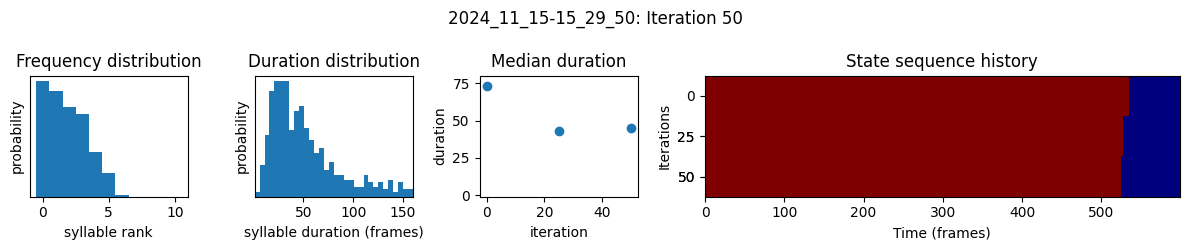

 25%|████████▍                         | 75/301 [03:22<10:15,  2.72s/it]

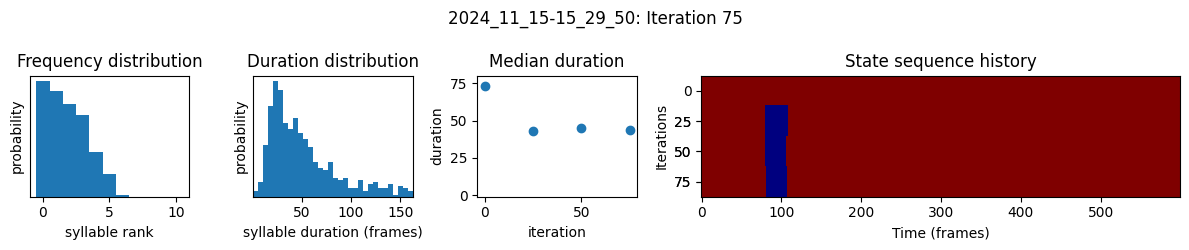

 33%|██████████▉                      | 100/301 [04:31<08:57,  2.67s/it]

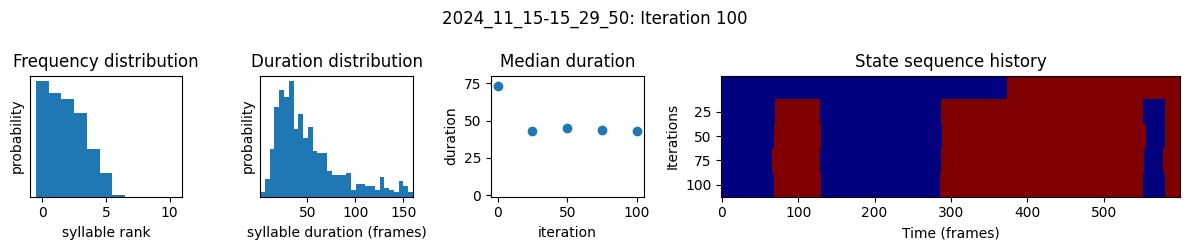

 42%|█████████████▋                   | 125/301 [05:39<08:01,  2.73s/it]

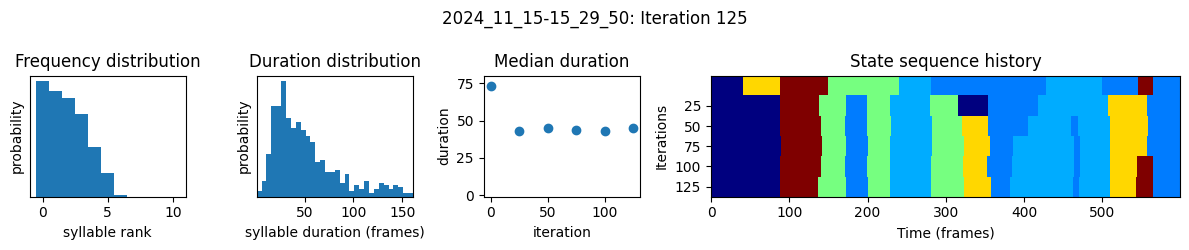

 50%|████████████████▍                | 150/301 [06:48<06:51,  2.72s/it]

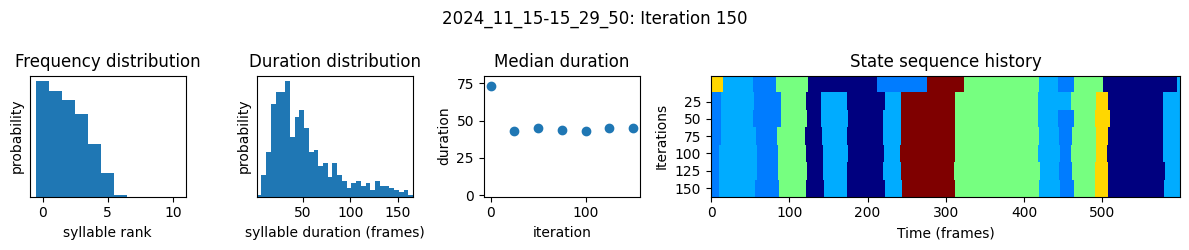

 58%|███████████████████▏             | 175/301 [07:57<05:41,  2.71s/it]

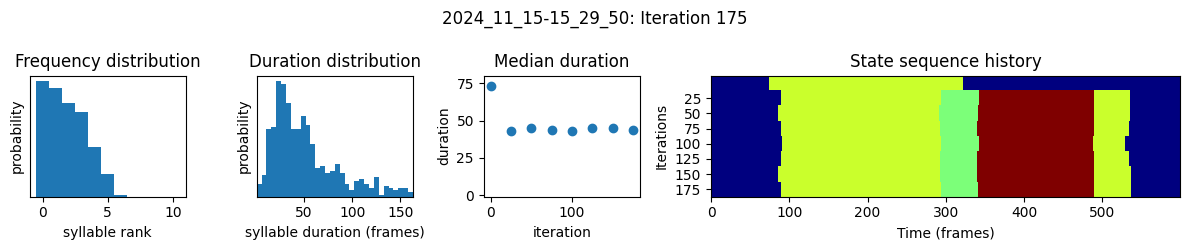

 66%|█████████████████████▉           | 200/301 [09:05<04:31,  2.69s/it]

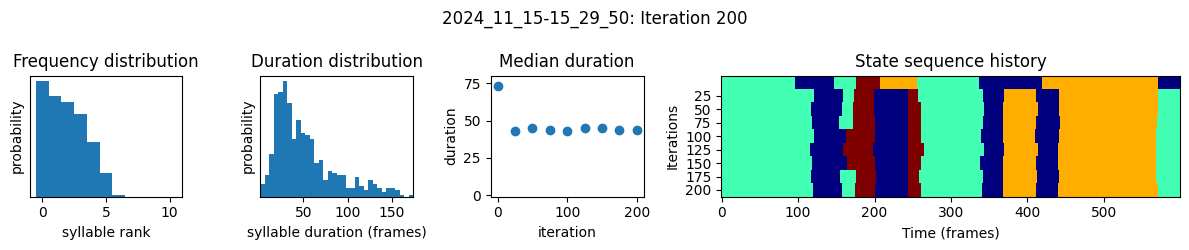

 75%|████████████████████████▋        | 225/301 [10:13<03:24,  2.69s/it]

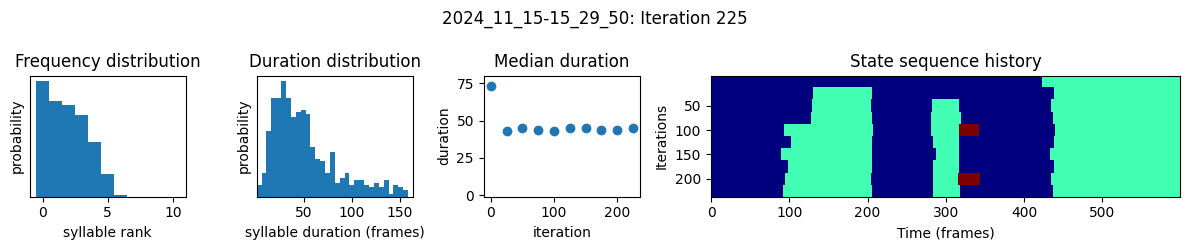

 83%|███████████████████████████▍     | 250/301 [11:21<02:19,  2.74s/it]

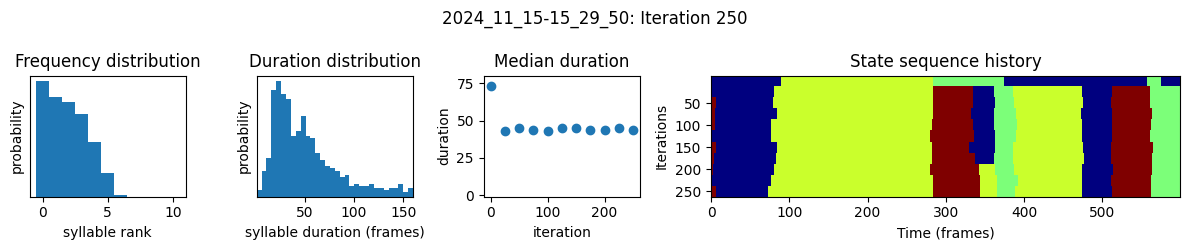

 91%|██████████████████████████████▏  | 275/301 [12:29<01:09,  2.67s/it]

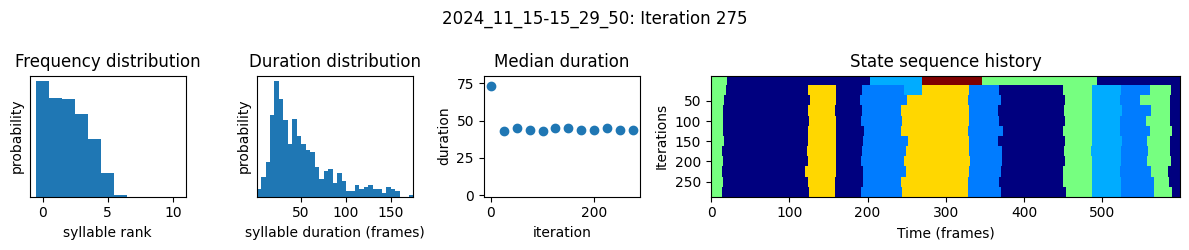

100%|████████████████████████████████▉| 300/301 [13:38<00:02,  2.80s/it]

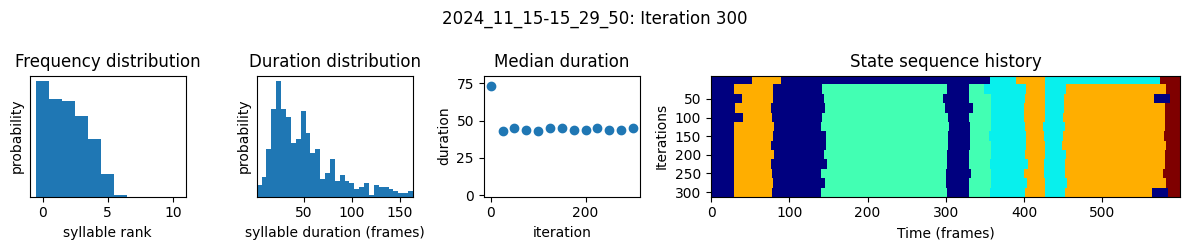

100%|█████████████████████████████████| 301/301 [13:42<00:00,  2.73s/it]


Setting up project for session 4.


Loading keypoints: 100%|██████████████████| 1/1 [00:00<00:00,  1.39it/s]


>=90.0% of variance exlained by 7 components.
Outputs will be saved to z:\Ben\Projects\StressDASert\Behavior\Scripts
\2024-09-27_KPMS_project\session_3\2024_11_15-15_43_36


  8%|██▊                               | 25/301 [01:07<12:19,  2.68s/it]

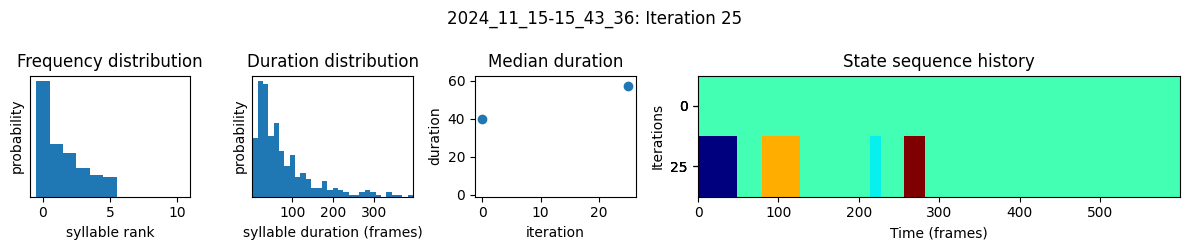

 17%|█████▋                            | 50/301 [02:16<11:17,  2.70s/it]

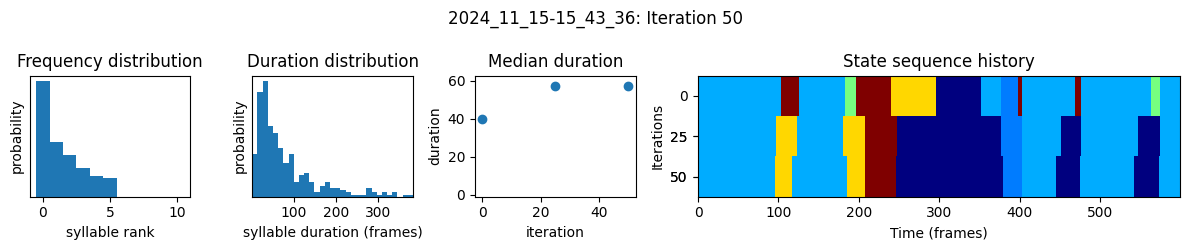

 25%|████████▍                         | 75/301 [03:24<10:09,  2.70s/it]

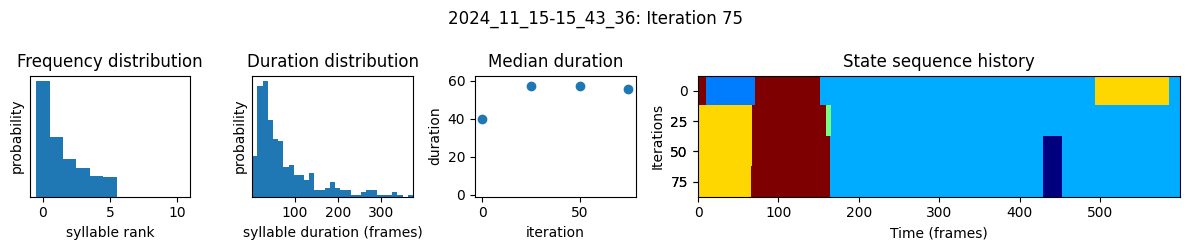

 33%|██████████▉                      | 100/301 [04:34<09:16,  2.77s/it]

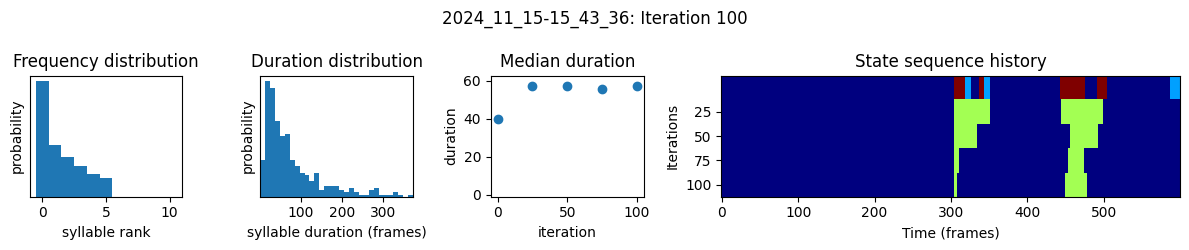

 42%|█████████████▋                   | 125/301 [05:42<07:58,  2.72s/it]

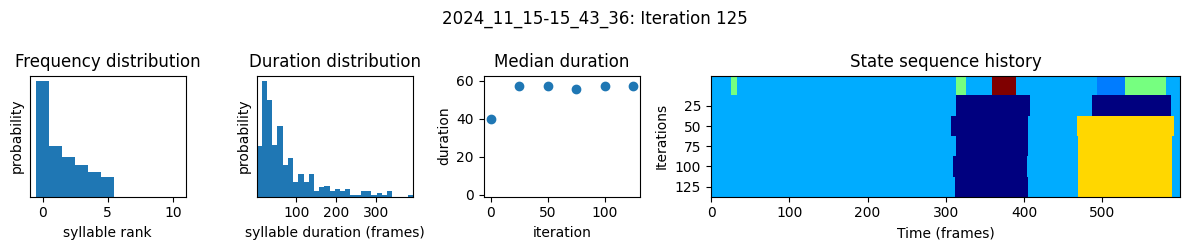

 50%|████████████████▍                | 150/301 [06:50<06:42,  2.66s/it]

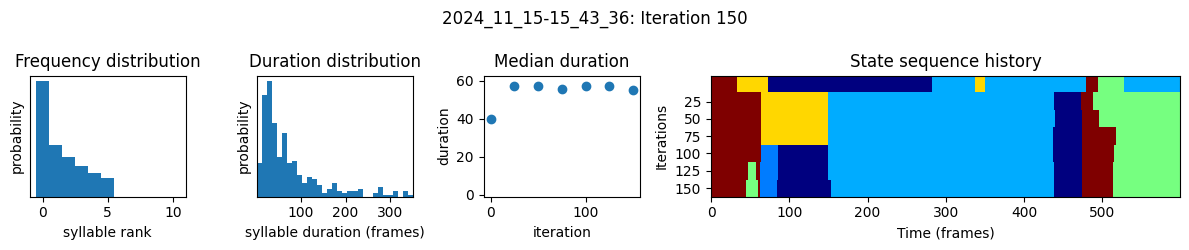

 58%|███████████████████▏             | 175/301 [07:58<05:42,  2.72s/it]

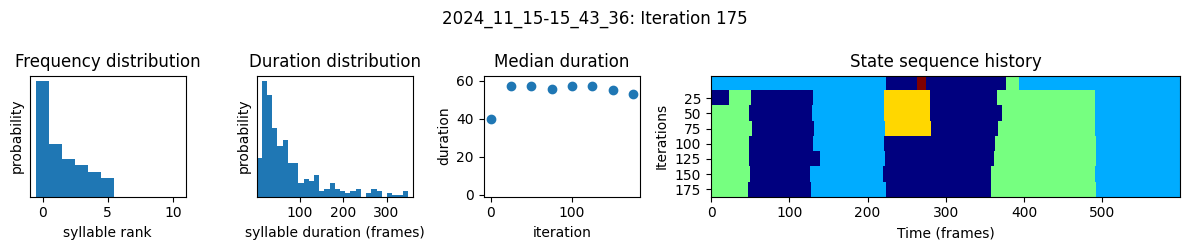

 66%|█████████████████████▉           | 200/301 [09:06<04:31,  2.69s/it]

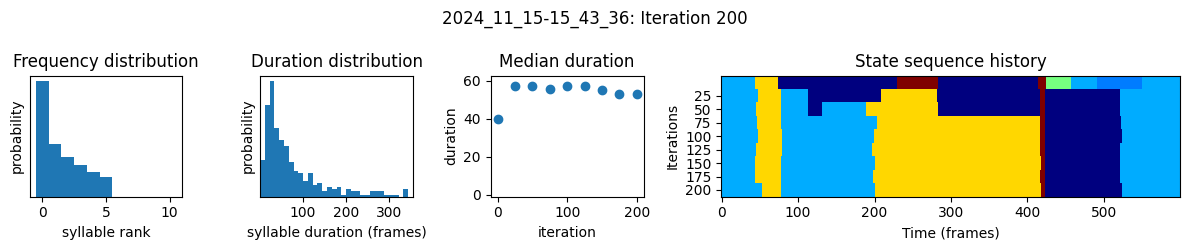

 75%|████████████████████████▋        | 225/301 [10:14<03:28,  2.75s/it]

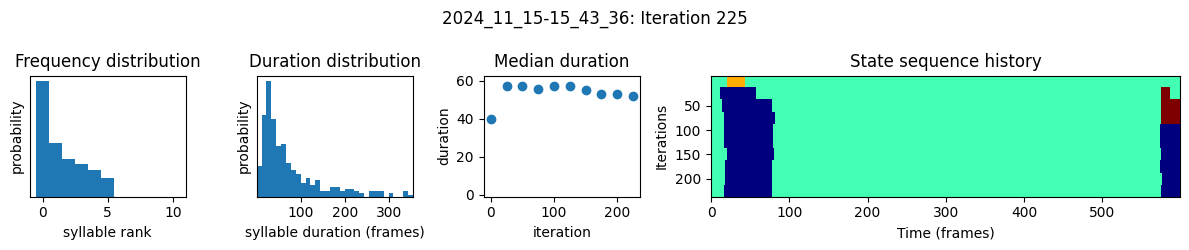

 83%|███████████████████████████▍     | 250/301 [11:23<02:17,  2.70s/it]

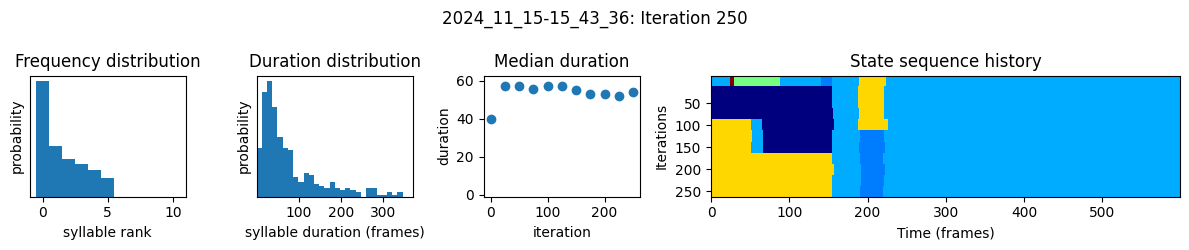

 91%|██████████████████████████████▏  | 275/301 [12:32<01:11,  2.74s/it]

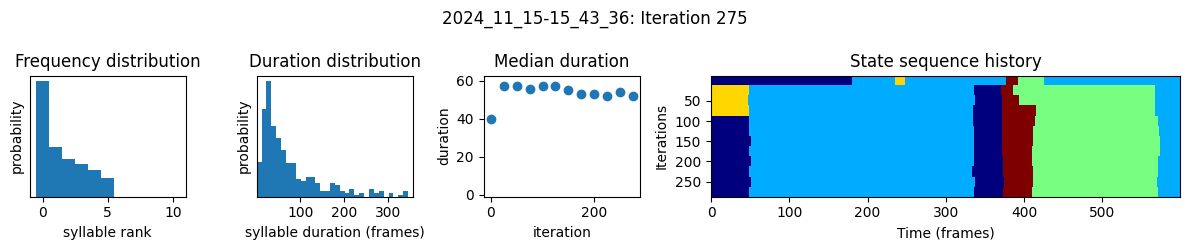

 94%|██████████████████████████████▉  | 282/301 [12:51<00:51,  2.70s/it]

In [ ]:
### Fit on each session in the experiment.

for i, session_dir in enumerate(session_directories):

    # Set up sub-project for current session.
    session_sub_dir = os.listdir(session_dir)[0]
    if ".DS_Store" in session_sub_dir:
        pass
    else:

        print(f"\n***Setting up project for session {session_dir[-1]}.***\n")
        
        # Set-up project.
        current_session_project_dir = os.path.join(experiment_project_filepath, f"session_{i}")
        current_session_Camera0_tracks_filepath = os.path.join(session_dir, session_sub_dir, "Camera0", "black_inference.slp")
        kpms.setup_project(current_session_project_dir, sleap_file=current_session_Camera0_tracks_filepath, overwrite=True)

        # Update config file with parameters for tracking.
        kpms.update_config(
            current_session_project_dir,
            video_dir=current_session_Camera0_tracks_filepath,
            anterior_bodyparts=["Nose"],
            posterior_bodyparts=["TTI"],
            use_bodyparts=["Nose", "Ear_L", "Ear_R", "Head", "Neck", "Shoulder_left",
                            "Shoulder_right", "Haunch_left", "Haunch_right", "Trunk", "TTI"] # Use everything but the tail.
        )

        # Function to load config file.
        config = lambda: kpms.load_config(current_session_project_dir)

        # Load data.
        session_3D_tracks_filepath = os.path.join(session_dir, session_sub_dir, "black_triangulated.h5")
        coordinates, confidences, bodyparts = kpms.load_keypoints(session_3D_tracks_filepath, "sleap-anipose")

        # Format data for modeling.
        data, metadata = kpms.format_data(coordinates, confidences, **config())

        # Fit PCA.
        pca = kpms.fit_pca(**data, **config())
        kpms.save_pca(pca, current_session_project_dir)
        kpms.print_dims_to_explain_variance(pca, 0.9)
        num_pcs_needed_for_90_var = int(np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.9)[0][0] + 1)
        kpms.update_config(current_session_project_dir, latent_dim=num_pcs_needed_for_90_var)

        ar_hmm_iters = 150
        slds_iters = 300

        # If this is the first session, run AR-HMM for initialization then SLDS off the initialization.
        if i == 0:

            # Run AR-HMM for initialization.
            model = kpms.init_model(data, pca=pca, **config(), location_aware=True)
            model = kpms.update_hypparams(model, kappa=1e9)
            model, model_name = kpms.fit_model(model, data, metadata, current_session_project_dir, ar_only=True, num_iters=ar_hmm_iters, model_name=f"session_{i}_model",location_aware=True)

            # Run SLDS off the initialization.
            model, data, metadata, current_iter = kpms.load_checkpoint(current_session_project_dir, model_name, iteration=ar_hmm_iters)
            model = kpms.update_hypparams(model, kappa=1e10)
            model = kpms.fit_model(model, data, metadata, current_session_project_dir, model_name, ar_only=False, start_iter=current_iter, num_iters=current_iter + slds_iters, location_aware=True)[0]
            
            # Save variable names to use for next session.
            prior_session_project_dir = current_session_project_dir
            prior_session_model_name = model_name

        # If not the first session, load model from previous session and run SLDS.
        else:

            # Load model from previous session.
            model = kpms.load_checkpoint(prior_session_project_dir, prior_session_model_name)[0]
            model = kpms.init_model(data, pca=pca, params=model["params"], hypparams=model["hypparams"], **config(), location_aware=True)

            # Run SLDS.
            model, model_name = kpms.fit_model(model, data, metadata, current_session_project_dir, ar_only=False, num_iters=slds_iters, model_name=f"session_{i}_model", location_aware=True)

            # Save variable names to use for next session.
            prior_session_project_dir = current_session_project_dir
            prior_session_model_name = model_name